_Neural Data Science_

Lecturer: Prof. Dr. Philipp Berens, Dr. Jan Lause

Tutors: Jonas Beck, Kyra Kadhim, Jonathan Oesterle, Julius Würzler

Summer term 2026

Student names: <span style='background: yellow'>Frauke von der Haar, Urmi Jana </span>

LLM Disclaimer: <span style='background: yellow'> Claude (Anthropic) was used throughout this project, primarily for debugging, statistical interpretation, and methodological review</span>

# Neural Data Science Project — Spike Inference

## Inferring spiking activity from calcium imaging data using deep learning

In this project you will train your own deep network to infer neuronal spiking activity from calcium imaging ΔF/F traces. You will work with ground truth data from simultaneous calcium imaging and electrophysiology recordings, preprocess it for training, build and train a neural network, and evaluate your model on held-out neurons.

You are free to use tools, resources and libraries as you see fit. Use comments and markdown cells to document your thought process and to explain your reasoning. We encourage you to compare different algorithms or to implement state of the art solutions. The notebook should be self contained, although you may offload some functions to a `utils.py`. The notebook should be concluded with a final summary / conclusions section.

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy.ndimage
from scipy.ndimage import gaussian_filter1d
from scipy.signal import resample
from scipy.stats import pearsonr

import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

In [2]:
# ---- House plotting style (used throughout the notebook) ----
import seaborn as sns  # imported once, here, near the top -- some plotting
                       # cells below use it and previously depended on a
                       # later cell having imported it first
# One color per indicator / condition, defined once here, so "6f" and "6s"
# (and later, each training condition) always mean the same color everywhere
# below -- rather than each cell picking its own hex codes.
INDICATOR_COLORS = {'6f': '#1f77b4', '6s': '#ff7f0e'}
CONDITION_COLORS = {
    '6f_only':          '#1f77b4',  # same blue as the 6f indicator
    '6s_only':          '#ff7f0e',  # same orange as the 6s indicator
    'mixed':            '#2ca02c',
    'noise_matched_6f': '#9467bd',
}
# External literature-model comparisons (Cascade anchor section) get their
# own neutral palette -- distinct from CONDITION_COLORS so a reader never
# confuses "which Cascade model" with "which of our own training regimes".
ANCHOR_COLORS = {
    'Global (universal)':          '#7f7f7f',
    'GC8s (mismatched indicator)': '#bcbd22',
}

mpl.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 150,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'legend.frameon': False,
    'axes.edgecolor': '#444444',
    'axes.linewidth': 0.9,
})

def style_axis(ax, grid_axis='y'):
    """Apply the house grid style to one axis. Call after plotting on it."""
    ax.grid(axis=grid_axis, alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    return ax


## Context

### Calcium imaging and spike inference

Two-photon calcium imaging records neural activity by measuring fluorescence of genetically encoded calcium indicators (e.g. GCaMP6f, GCaMP6s). When a neuron fires an action potential, calcium flows into the cell, causing the indicator to fluoresce more brightly. The resulting signal — expressed as **ΔF/F** (relative fluorescence change) — is a noisy, temporally smoothed version of the true spiking activity:

- A single action potential produces a fast rise (~50 ms) followed by a slow exponential decay (~200–1000 ms, depending on the indicator)
- The signal is corrupted by shot noise, neuropil contamination, and motion artifacts
- Multiple spikes in quick succession sum nonlinearly

**Spike inference** (also called deconvolution) is the inverse problem of recovering the underlying spike times or spike rates from the observed ΔF/F traces.

### Cascade as a reference

In this project you will train your own neural network for the task of spike inference, similar to what was done in [**Cascade**](https://github.com/HelmchenLabSoftware/Cascade) (Rupprecht et al., *Nature Neuroscience*, 2021). Cascade trains a simple 1D convolutional network (~50k parameters) on a large database of simultaneous calcium imaging and electrophysiology recordings. A key part of their approach is a noise-matched training procedure that resamples the ground truth data to match the noise level and frame rate of any target recording, making the trained models robust across different experimental conditions. Cascade also provides pretrained models for common configurations that can serve as performance baselines.

You can use their code, preprocessing routines, and pretrained models as a reference. The PyTorch implementation is available at [CascadeTorch](https://github.com/PTRRupprecht/CascadeTorch).

**Paper:** Rupprecht P, Carta S, Hoffmann A, Echizen M, Blot A, Kwan AC, Dan Y, Hofer SB, Kitamura K, Helmchen F\*, Friedrich RW\*. *A database and deep learning toolbox for noise-optimized, generalized spike inference from calcium imaging.* Nature Neuroscience (2021). [Link](https://www.nature.com/articles/s41593-021-00895-5)

### The data

The file `spike_inference_data.npz` contains ground truth recordings from simultaneous calcium imaging and electrophysiology. Each recording provides:

| Field | Description |
|---|---|
| `dff` | ΔF/F fluorescence trace (1D float array) |
| `t` | Time vector in seconds (1D float array) |
| `spikes` | Action potential times in seconds (1D float array) |
| `frame_rates` | Imaging frame rate in Hz (scalar) |
| `datasets` | Source dataset identifier (string) |

The data is split into:

- **Training recordings** (`train_*`): Use these to build your preprocessing pipeline and train your network. They come from 4 ground truth datasets recorded with GCaMP6f and GCaMP6s in mouse visual cortex.
- **Test recordings** (`test_*`): A held-out dataset for final evaluation. Do not use these for training.

All recordings were obtained at ~60 Hz and can be resampled to a lower frame rate (e.g. 30 Hz) during preprocessing.

In [3]:
# load data
def load_data(path="./data"):
    data = np.load(path + "/spike_inference_data.npz", allow_pickle=True)
    return dict(data)

def print_info(data):
    for key in sorted(data.keys()):
        arr = data[key]
        if arr.dtype == object:
            print(f"  [{key:25s}]  {arr.shape}  (variable-length arrays)")
        else:
            print(f"  [{key:25s}]  {arr.shape}  dtype={arr.dtype}")

data = load_data()

print("Overview of the data")
print_info(data)
print(f"\nTraining datasets: {list(data['train_dataset_names'])}")
print(f"Test datasets:     {list(data['test_dataset_names'])}")
print(f"Training recordings: {len(data['train_dff'])}")
print(f"Test recordings:     {len(data['test_dff'])}")

Overview of the data
  [test_dataset_names       ]  (1,)  dtype=<U17
  [test_datasets            ]  (9,)  (variable-length arrays)
  [test_dff                 ]  (9,)  (variable-length arrays)
  [test_filenames           ]  (9,)  (variable-length arrays)
  [test_frame_rates         ]  (9,)  dtype=float64
  [test_spikes              ]  (9,)  (variable-length arrays)
  [test_t                   ]  (9,)  (variable-length arrays)
  [train_dataset_names      ]  (4,)  dtype=<U36
  [train_datasets           ]  (83,)  (variable-length arrays)
  [train_dff                ]  (83,)  (variable-length arrays)
  [train_filenames          ]  (83,)  (variable-length arrays)
  [train_frame_rates        ]  (83,)  dtype=float64
  [train_spikes             ]  (83,)  (variable-length arrays)
  [train_t                  ]  (83,)  (variable-length arrays)

Training datasets: [np.str_('DS09-GCaMP6f-m-V1'), np.str_('DS10-GCaMP6f-m-V1-neuropil-corrected'), np.str_('DS14-GCaMP6s-m-V1'), np.str_('DS15-GCaMP6s-m-V

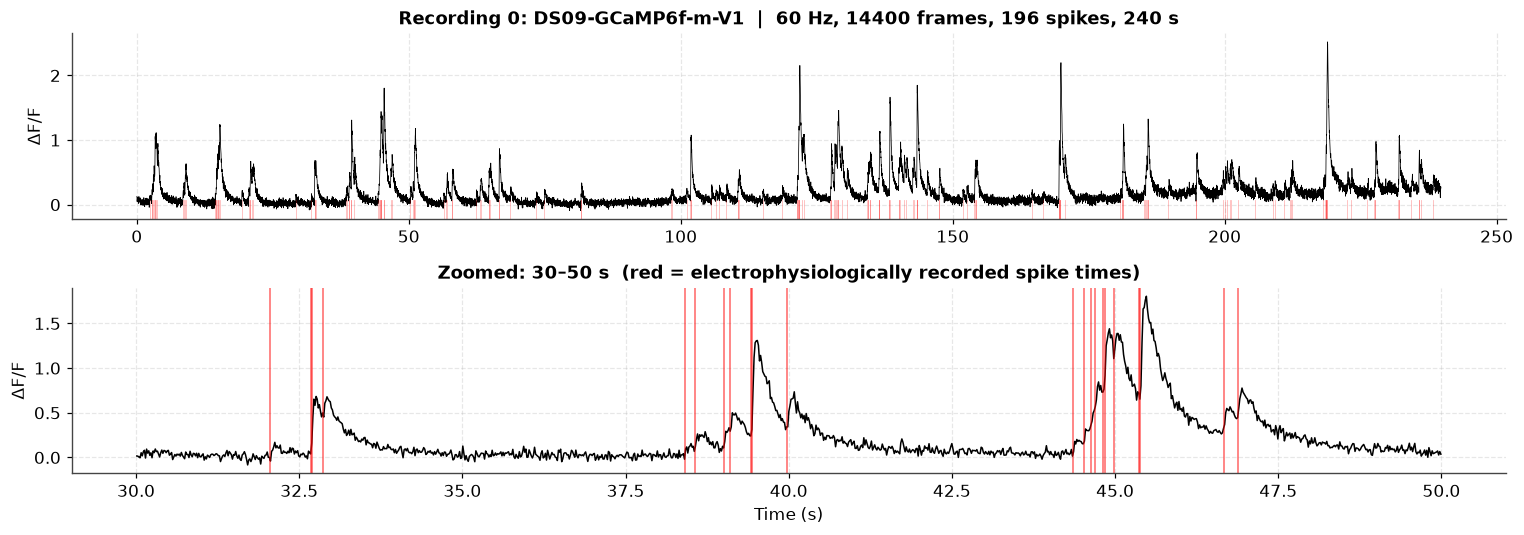

In [4]:
# Visualize an example training recording
idx = 0  # change this to browse different recordings
dff = data['train_dff'][idx]
t = data['train_t'][idx]
spikes = data['train_spikes'][idx]
fr = data['train_frame_rates'][idx]
ds_name = str(data['train_datasets'][idx])

fig, axes = plt.subplots(2, 1, figsize=(14, 5))

# Full trace
axes[0].plot(t, dff, 'k', linewidth=0.5)
for sp in spikes:
    axes[0].axvline(sp, color='red', alpha=0.3, linewidth=0.5, ymin=0, ymax=0.1)
axes[0].set_ylabel('ΔF/F')
axes[0].set_title(f'Recording {idx}: {ds_name}  |  {fr:.0f} Hz, {len(dff)} frames, '
                  f'{len(spikes)} spikes, {t[-1]:.0f} s')

# Zoomed window
t0, t1 = 30, 50
m = (t >= t0) & (t <= t1)
axes[1].plot(t[m], dff[m], 'k', linewidth=1)
for sp in spikes[(spikes >= t0) & (spikes <= t1)]:
    axes[1].axvline(sp, color='red', alpha=0.6, linewidth=1)
axes[1].set_ylabel('ΔF/F')
axes[1].set_xlabel('Time (s)')
axes[1].set_title(f'Zoomed: {t0}–{t1} s  (red = electrophysiologically recorded spike times)')

plt.tight_layout()
plt.show()

## Research question

<span style='background: yellow'>
Investigating and Mitigating Domain Shift in Deep Learning-Based Spike Inference Across Calcium Indicators
Does spike inference exhibit asymmetric generalization between GCaMP6f and GCaMP6s?
Can mixed-indicator training reduce this domain shift? How does the model architecture affect spike inference performance?
</span>

Some possible directions (pick one, or formulate your own):

1. **Train a spike inference network and evaluate its generalization.** Build a preprocessing pipeline (resampling, noise augmentation, windowing, target smoothing), train a neural net, and evaluate on the held-out test set. How does performance depend on the training data composition and noise level?

2. **Compare architectures.** Implement at least two different network architectures (e.g. the Cascade default, a deeper/shallower variant, one with skip connections or batch normalization). Which design choices matter most for spike inference performance?

3. **How does temporal smoothing of the ground truth affect inference quality?** Train models with different smoothing kernels (e.g. 25, 50, 100, 200 ms) and evaluate the trade-off between temporal precision and robustness. Optionally compare symmetric vs. causal smoothing kernels.

4. **How well does a network trained on one indicator generalize to another?** Train on GCaMP6f data only and test on GCaMP6s (or vice versa). How much does indicator-specific training improve performance?

Implement all steps necessary to answer your question. Think of: preprocessing, model design, training, evaluation, and visualization. The notebook should be concluded with a summary / conclusions section.

In [5]:

%load_ext autoreload
%autoreload 2

import utils
import warnings
import importlib
%reload_ext autoreload
warnings.warn("Test ")

%aimport -torch
importlib.reload(utils)
print(dir(utils))

['Any', 'Cascade1DCNN', 'DataLoader', 'Dict', 'List', 'Optional', 'TensorDataset', 'Tuple', 'WeightedRandomSampler', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', '_shift_and_truncate', 'apply_lag', 'augment_train_noise', 'bin_discrete_spikes', 'bounded_cross_correlation_alignment', 'cheby1', 'compute_dynamic_dff', 'compute_noise_ceiling', 'correct_dff_baseline_drift', 'create_balanced_dataloader', 'evaluate_predictions', 'f1_score', 'filter_by_indicator', 'find_best_lag', 'fit_dataset_level_lag', 'gaussian_filter1d', 'generate_sliding_windows', 'get_dynamic_snr_threshold', 'get_indicator', 'interp1d', 'nn', 'np', 'partition_recordings', 'pearsonr', 'percentile_filter', 'robust_quality_control', 'scale_features', 'smooth_spike_train', 'sosfiltfilt', 'standardize_trace', 'torch', 'train_model', 'uniform_filter1d', 'warnings']


/tmp/ipykernel_31220/3373541493.py:8: UserWarning: Test 
  warnings.warn("Test ")


## Data exploration 

In [6]:
from utils import  get_indicator

# Minimun frame rate
print(f"Training FR - Min: {np.min(data['train_frame_rates']):.2f} Hz, Max: {np.max(data['train_frame_rates']):.2f} Hz")
print(f"Testing FR - Min: {np.min(data['train_frame_rates']):.2f} Hz, Max: {np.max(data['test_frame_rates']):.2f} Hz")

test_ds_names = sorted(set(str(d) for d in data['test_dataset_names']))
train_ds_names = sorted(set(str(d) for d in data['train_dataset_names']))

indicator_of = {'DS09': '6f', 'DS10': '6f', 'DS14': '6s', 'DS15': '6s', 'DS16': '6s'}



train_indicators = sorted(set(get_indicator(d) for d in train_ds_names))
test_indicators  = sorted(set(get_indicator(d) for d in test_ds_names))
print("Train indicators:", train_indicators)
print("Test indicators: ", test_indicators)

print("Train datasets:", train_ds_names)
print("Test datasets: ", test_ds_names)

from collections import Counter
print(Counter(str(d) for d in data['test_datasets']))  # per-recording, not just unique names


from collections import defaultdict

fr_by_dataset = defaultdict(list)
for ds, fr in zip(data['train_datasets'], data['train_frame_rates']):
    fr_by_dataset[str(ds)].append(fr)

for ds, frs in sorted(fr_by_dataset.items()):
    print(f"{ds}: n={len(frs)}, FR range=[{min(frs):.1f}, {max(frs):.1f}]")




Training FR - Min: 59.06 Hz, Max: 179.86 Hz
Testing FR - Min: 59.06 Hz, Max: 59.10 Hz
Train indicators: ['6f', '6s']
Test indicators:  ['6s']
Train datasets: ['DS09-GCaMP6f-m-V1', 'DS10-GCaMP6f-m-V1-neuropil-corrected', 'DS14-GCaMP6s-m-V1', 'DS15-GCaMP6s-m-V1']
Test datasets:  ['DS16-GCaMP6s-m-V1']
Counter({'DS16-GCaMP6s-m-V1': 9})
DS09-GCaMP6f-m-V1: n=33, FR range=[60.1, 60.1]
DS10-GCaMP6f-m-V1-neuropil-corrected: n=23, FR range=[158.3, 179.9]
DS14-GCaMP6s-m-V1: n=18, FR range=[60.1, 60.1]
DS15-GCaMP6s-m-V1: n=9, FR range=[59.1, 59.1]


 📝 **Personal note.** project guideline recommends downsampling to 30 HZ , but why not to just the min Framrerate
 built in noise filter
 computational efficiency 

# Overall Pipeline

All recordings undergo the same preprocessing sequence before model training. During evaluation, held-out datasets pass through the identical preprocessing pipeline, but any parameters that require fitting (e.g., feature-scaling statistics or noise augmentation targets) are estimated exclusively from the corresponding training fold to prevent information leakage.

**Status.** Preprocessing (Steps 0-5), LODO fold/condition construction (Steps 6-7d), the full LODO training grid (Steps 8-11), and the final held-out test-set run (Step 12) are all complete and verified against the real data (see the printed diagnostics in each section). A Cascade literature-anchor comparison, added afterward and not part of the original plan below, has its own section near the end.

## Step 0 — Dataset Inspection

| Step | What happens | Function(s) |
|---|---|---|

| 0a | Verify the composition of the official held-out test set | Notebook |

---

# Preprocessing Pipeline -- done

| Step | What happens | Function |
|---|---|---|
| 1 | Resample every ΔF/F trace onto a uniform 30 Hz temporal grid | `standardize_trace` |
| 2 | Convert continuous spike timestamps into discrete per-frame spike counts | `bin_discrete_spikes` |
| 2b | Evaluate potential hardware synchronization lag (measured but deliberately not corrected to avoid confounding indicator kinetics) | `fit_dataset_level_lag`, `bounded_cross_correlation_alignment` |
| 3 | Remove slow baseline drift from the already-computed ΔF/F traces | `correct_dff_baseline_drift` |
| 4 | Exclude recordings with insufficient spike activity or poor signal quality | `robust_quality_control` |
| 5 | Transform discrete spike counts into continuous Gaussian-smoothed firing-rate targets (Hz) | `smooth_spike_train` |

---

# Cross-Validation Fold Construction -- done

| Step | What happens |
|---|---|
| 6 | Construct Leave-One-Dataset-Out (LODO) folds, holding out one source dataset at a time |
| 7a | For **every** LODO fold and **every** condition, augment training recordings to match that fold's own noise ceiling, fit from the training pool only -- never from the held-out data |
| 7b | Convert continuous recordings into fixed-length CNN input windows (stride 2) |
| 7c | Z-score inputs using statistics computed exclusively from the current training fold, fit once per fold and reused identically across conditions |
| 7d | Build indicator-balanced `DataLoader`s per fold × condition and export the arrays to disk |

---

# Training and Evaluation -- done

| Step | What happens |
|---|---|
| 8 | Train the network on each fold × condition's `DataLoader` under multiple random seeds |
| 9 | Aggregate performance across LODO folds and seeds (mean ± standard deviation) |
| 10 | Estimate the within-indicator transfer floor by measuring cross-dataset generalization while keeping the calcium indicator fixed |
| 11 | Compare within- and cross-indicator transfer performance (`6f→6f`, `6s→6s`, `6f→6s`, `6s→6f`) to isolate the contribution of indicator-specific domain shift |
| 12 | Select the best-performing training regime from LODO, then run it once, frozen, on the true held-out test set (`test_dff` / DS16) |

---

## Evaluation Logic

The LODO evaluation framework is designed to separate dataset-specific variation from calcium-indicator-specific domain shift:

- **Within-indicator transfer** (`6f→6f`, `6s→6s`) estimates the expected performance limit when the indicator remains unchanged but the recording dataset differs.
- **Cross-indicator transfer** (`6f→6s`, `6s→6f`) measures the additional challenge introduced by indicator kinetics.
- The difference between these conditions quantifies the contribution of indicator-specific domain shift relative to general dataset variation.

This design prevents information leakage, ensures identical preprocessing for training and evaluation data, and directly addresses the central research question of how robust spike inference models are across calcium indicators. **Caveat worth stating up front, not discovering later: with only 2 GCaMP6f and 2 GCaMP6s training datasets, each within-indicator transfer estimate rests on n=2 dataset pairs. That's enough to report a direction and an effect size, not enough to support a confident significance claim -- the results section should say so explicitly rather than implying a confirmatory test.**

### Step 1 — Temporal Standardization
`standardize_trace()` · `utils.py`

**Problem.** Raw ΔF/F traces aren't sampled at a perfectly uniform rate, and exact frame rates vary slightly across recordings (~59–61 Hz here). A 1D-CNN needs the same physical duration to be represented by the same number of frames in every recording, or it can't learn one consistent temporal kernel (e.g. for the ~50 ms GCaMP rise time).

**Solution.** Every trace is resampled onto a single uniform 30 Hz grid. When a recording needs downsampling, an 8th-order Chebyshev Type I low-pass filter is applied first (zero-phase, via `sosfiltfilt`), then linearly interpolated onto the exact target grid. If the native rate is already ≤ 30 Hz, filtering is skipped since there's no aliasing risk.

**Why.** Resampling without filtering first lets high-frequency content (shot noise, motion artifacts) fold back down into the calcium-transient band, corrupting the trace permanently.

**Why not.** Cutting off exactly at the new Nyquist frequency would still leak some aliased energy, since Chebyshev filters roll off gradually rather than instantly — hence the small safety margin below it.


In [7]:
from utils import standardize_trace

TARGET_FS = 30.0  # Hz - global standard for the whole project

phase1_data = {}

print(f"Resampling continuous traces to {TARGET_FS} Hz...")

for idx in range(len(data['train_dff'])):
    raw_dff = data['train_dff'][idx]
    raw_t = data['train_t'][idx]

    # Anti-aliased resampling onto the uniform target grid
    dff_res, t_res = standardize_trace(dff=raw_dff, t=raw_t, target_fs=TARGET_FS)

    # Keep everything needed for the next preprocessing steps together,
    # keyed by recording index so nothing gets misaligned downstream.
    phase1_data[idx] = {
        'dff': dff_res,                              # resampled dF/F trace
        'frame_times': t_res,                        # resampled, uniform time vector
        'spikes': data['train_spikes'][idx],         # RAW spike times (point events - not resampled)
        'dataset': str(data['train_datasets'][idx]),
        'filename': str(data['train_filenames'][idx]),
        'orig_frame_rate': data['train_frame_rates'][idx],
    }

print(f"Successfully resampled {len(phase1_data)} recordings.")
print(f"Recording 0 - Original shape: {data['train_dff'][0].shape} "
      f"(~{data['train_frame_rates'][0]:.1f} Hz)")
print(f"Recording 0 - New shape:      {phase1_data[0]['dff'].shape} ({TARGET_FS} Hz)")


Resampling continuous traces to 30.0 Hz...
Successfully resampled 83 recordings.
Recording 0 - Original shape: (14400,) (~60.1 Hz)
Recording 0 - New shape:      (7193,) (30.0 Hz)


> 📝 **Personal note.** The original version of this function returned `dff_standard,` — a trailing comma that silently turned the return value into a 1-tuple and dropped `t_standard` entirely. Python doesn't complain about that at all;
>  worth double-checking multi-return functions actually unpack the way expected, especially after a refactor.
>
>  — worth remembering *why* you filter before you downsample, not just that you do.

In [8]:
### Sanity check 

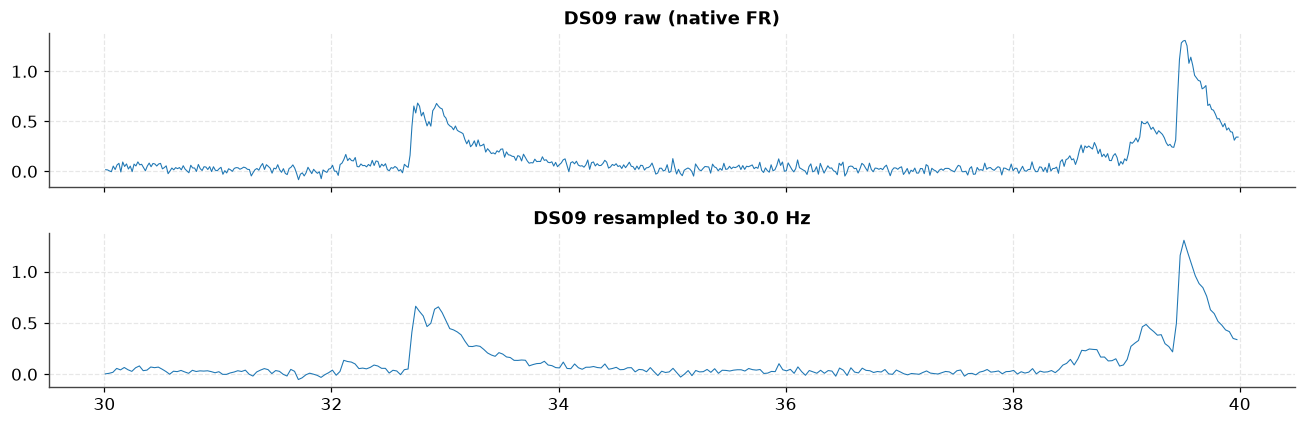

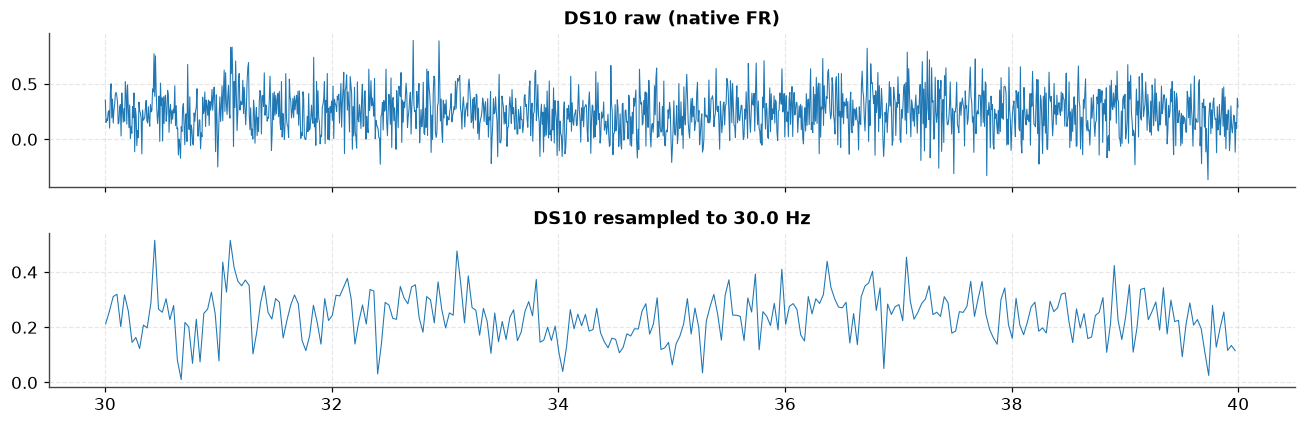

In [9]:
# Compare a DS09 (typical 60 Hz ) and DS10 (outlier 170 Hz ) recording before/after resampling
for ds_check in ['DS09', 'DS10']:
    idx = next(i for i in range(len(data['train_dff']))
               if str(data['train_datasets'][i]).startswith(ds_check))
    raw_dff, raw_t = data['train_dff'][idx], data['train_t'][idx]
    dff_res, t_res = standardize_trace(dff=raw_dff, t=raw_t, target_fs=TARGET_FS)

    fig, axes = plt.subplots(2, 1, figsize=(12, 4), sharex=True)
    m_raw = (raw_t >= 30) & (raw_t <= 40)
    m_res = (t_res >= 30) & (t_res <= 40)
    axes[0].plot(raw_t[m_raw], raw_dff[m_raw], lw=0.7); axes[0].set_title(f'{ds_check} raw (native FR)')
    axes[1].plot(t_res[m_res], dff_res[m_res], lw=0.7);  axes[1].set_title(f'{ds_check} resampled to {TARGET_FS} Hz')
    plt.tight_layout(); plt.show()

In [10]:
def noise_level(dff, fr):
    return np.median(np.abs(np.diff(dff))) / np.sqrt(fr)

rows = []
for idx in range(len(data['train_dff'])):
    ds  = str(data['train_datasets'][idx])
    dff = data['train_dff'][idx]
    fr  = data['train_frame_rates'][idx]
    rows.append(dict(dataset=ds, noise_level=noise_level(dff, fr),
                      peak99=np.percentile(dff, 99), median=np.median(dff)))

df_noise = pd.DataFrame(rows)
print(df_noise.groupby('dataset')['noise_level'].describe())

                                      count      mean       std       min  \
dataset                                                                     
DS09-GCaMP6f-m-V1                      33.0  0.004055  0.001224  0.002582   
DS10-GCaMP6f-m-V1-neuropil-corrected   23.0  0.004631  0.002171  0.002680   
DS14-GCaMP6s-m-V1                      18.0  0.005293  0.001628  0.002898   
DS15-GCaMP6s-m-V1                       9.0  0.006926  0.002211  0.004789   

                                           25%       50%       75%       max  
dataset                                                                       
DS09-GCaMP6f-m-V1                     0.003151  0.003819  0.004165  0.007334  
DS10-GCaMP6f-m-V1-neuropil-corrected  0.003082  0.004235  0.005405  0.012967  
DS14-GCaMP6s-m-V1                     0.003705  0.005564  0.006147  0.008802  
DS15-GCaMP6s-m-V1                     0.005329  0.006093  0.008026  0.010522  


#### Sanity check -- does DS10's native frame rate introduce an indicator-correlated confound?

DS10 (100% GCaMP6f) was recorded natively at 158-180 Hz, vs. ~60 Hz for DS09/DS14/DS15.
Every recording is downsampled to the same `TARGET_FS = 30 Hz` with an anti-alias filter
cutoff fixed at `0.9 * TARGET_FS / 2` regardless of source -- but that means DS10 is having a
much larger share of its own native bandwidth discarded than the other three datasets, purely
as a side effect of its own acquisition rate, not anything biological. Because DS10 is
entirely one indicator, this is the same category of risk as the lag-correction confound
already identified and avoided in Step 2b: an indicator-correlated *preprocessing* difference
that could be mistaken for an indicator-correlated *biological* one. This cell just makes the
asymmetry visible -- it doesn't attempt to correct for it, since what (if anything) to do
about it is a judgment call, not a bug fix.

Fixed AA filter cutoff for every recording: 13.5 Hz

                                     native_fr                            \
                                         count        mean           std   
dataset                                                                    
DS09-GCaMP6f-m-V1                         33.0   60.060060  1.012679e-14   
DS10-GCaMP6f-m-V1-neuropil-corrected      23.0  160.079083  4.870744e+00   
DS14-GCaMP6s-m-V1                         18.0   60.060060  9.118948e-15   
DS15-GCaMP6s-m-V1                          9.0   59.079312  2.439974e-02   

                                                                          \
                                             min         25%         50%   
dataset                                                                    
DS09-GCaMP6f-m-V1                      60.060060   60.060060   60.060060   
DS10-GCaMP6f-m-V1-neuropil-corrected  158.280441  158.280441  158.280441   
DS14-GCaMP6s-m-V1                 

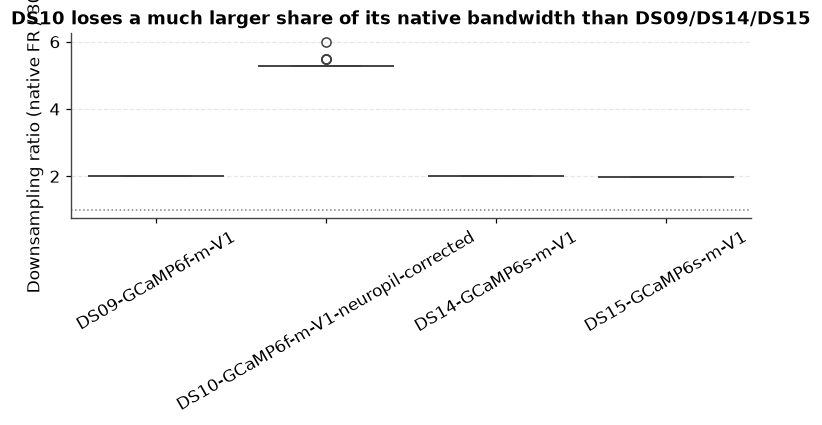

In [11]:
downsample_stats = []
for idx in range(len(data['train_dff'])):
    ds = str(data['train_datasets'][idx])
    fr = data['train_frame_rates'][idx]
    downsample_stats.append(dict(
        dataset=ds,
        indicator=get_indicator(ds),
        native_fr=fr,
        downsample_ratio=fr / TARGET_FS,
    ))

df_downsample = pd.DataFrame(downsample_stats)
print(f"Fixed AA filter cutoff for every recording: {0.9 * TARGET_FS / 2:.1f} Hz\n")
print(df_downsample.groupby('dataset')[['native_fr', 'downsample_ratio']].describe())

fig, ax = plt.subplots(figsize=(7, 4))
dataset_order = sorted(df_downsample['dataset'].unique())
dataset_palette = {d: INDICATOR_COLORS[get_indicator(d)] for d in dataset_order}
sns.boxplot(data=df_downsample, x='dataset', y='downsample_ratio', order=dataset_order,
            hue='dataset', palette=dataset_palette, legend=False, ax=ax)
ax.set_xlabel('')
ax.set_ylabel('Downsampling ratio (native FR / 30 Hz)')
ax.axhline(1.0, color='gray', linestyle=':', linewidth=1)
ax.set_title('DS10 loses a much larger share of its native bandwidth than DS09/DS14/DS15')
ax.tick_params(axis='x', rotation=30)
style_axis(ax)
plt.tight_layout()
plt.show()

### Step 2 — Discrete Event Binning
`bin_discrete_spikes()` · `utils.py`

**Problem.** Spikes are timestamped continuously (electrophysiology clock); the resampled ΔF/F is discrete (camera frames). Every spike has to be assigned to exactly one frame, with none silently lost or double-counted.

**Solution.** Build bin edges at the midpoints between consecutive frame timestamps (plus extrapolated edges at the two ends), then histogram the spike times into those edges.

**Why.** Midpoint edges give the least-biased assignment when frame intervals aren't perfectly uniform, and they let spike conservation be checked explicitly — the sum of the binned counts must equal the number of spikes that actually fall inside the recording window.

**Why not.** A fixed-width bin (e.g. `[frame, frame + dt)`) is simpler but systematically biases spikes near a boundary toward the earlier frame; midpoint edges center each bin on its own frame instead.


### Step 2b -- Hardware Lag Correction: Evaluated and Skipped
`fit_dataset_level_lag()` / `bounded_cross_correlation_alignment()` · `utils.py` -- *available, not used here*

**Problem.** Optical and electrical acquisition systems can have a small, fixed synchronization offset. `utils.py` provides two ways to estimate and correct it: a per-recording fit and a more robust per-source-dataset fit.

**Solution.** Skip it -- assume negligible hardware lag (0 frames) rather than fitting one from this data.

**Why.** Both available methods estimate the lag by maximizing correlation between ΔF/F and binned spikes, so the result reflects the calcium indicator's own rise/decay kinetics as much as any real delay -- demonstrated with a reproducible synthetic test in the next two cells, rather than asserted: a zero-true-lag GCaMP6f-like kernel still gets "corrected" by tens of ms, a GCaMP6s-like kernel by roughly double that, from kinetics alone. In this project, every source dataset maps to exactly one indicator (`DS09`/`DS10` = GCaMP6f, `DS14`/`DS15`/`DS16` = GCaMP6s), so a per-*dataset* fit is mathematically identical to a per-*indicator* fit here. Applying either method would bake a different, indicator-correlated time shift into the data before training -- for the same reason it's unsafe to fit a lag on the held-out test set: the "correction" would be derived from the very signal whose cross-indicator comparison is the actual research question.

**Why not** *(the alternative, i.e. fitting a lag anyway)*. Even the more robust dataset-level fit doesn't avoid this: pooling within one indicator's recordings reduces recording-to-recording noise, but still converges on that indicator's own kinetics-driven bias, not a true hardware offset. These recordings also appear to come from Cascade's published ground-truth database, where calcium and electrophysiology are synchronized at acquisition -- a documented rig constant, if one existed, would be the only safe way to add lag correction back in.

#### Reproducible check -- how much lag would kinetics alone fake?

**Theoretical Hypothesis.** If lag-fitting on this data is really just re-discovering each indicator's own rise/decay shape rather than a true hardware offset, then applying the same logic to a *synthetic* trace built from a spike train with a **known, true lag of zero** should still report a large, nonzero "best lag" -- and that fake lag should be bigger for the slower indicator (GCaMP6s) than the faster one (GCaMP6f).

True lag: 0 ms (by construction)
6f-like kernel (50/200 ms rise/decay):  'best lag' found = 2 frames = 66.7 ms
6s-like kernel (50/1000 ms rise/decay): 'best lag' found = 5 frames = 166.7 ms


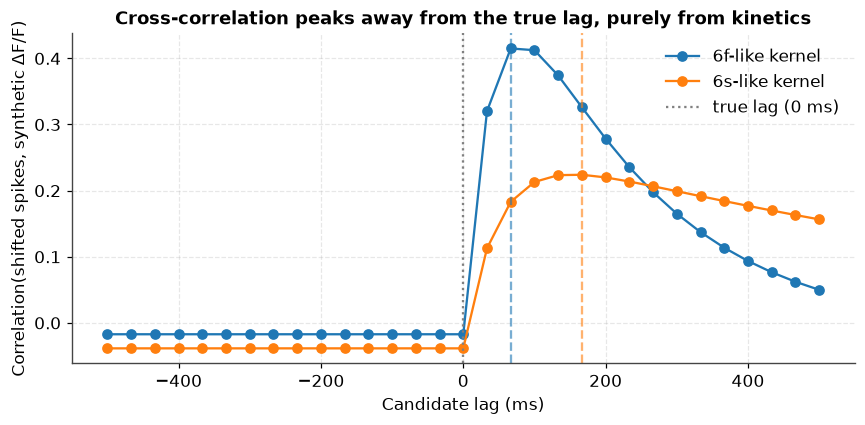

In [12]:
# Self-contained synthetic test (doesn't call utils.py internals, so it
# can't silently go stale if find_best_lag / bounded_cross_correlation_alignment
# change): convolve a spike train with a physiologically-typical GCaMP6f-like
# and GCaMP6s-like kernel at TRUE lag = 0, then ask a simple cross-correlation
# lag-finder what lag it thinks best re-aligns the trace to the spikes.
fps = TARGET_FS  # TARGET_FRAME_RATE is only defined a couple cells further down; same value

def gcamp_kernel(tau_rise, tau_decay, fps, duration=3.0):
    t = np.arange(0, duration, 1 / fps)
    k = (1 - np.exp(-t / tau_rise)) * np.exp(-t / tau_decay)
    return k / k.sum()

n_frames = int(30 * fps)
spike_frames = [100, 300, 500, 700]  # isolated, well-separated -> responses don't overlap
synthetic_spikes = np.zeros(n_frames)
for f in spike_frames:
    synthetic_spikes[f] = 1.0

kernel_6f = gcamp_kernel(0.05, 0.20, fps)   # ~50 ms rise, ~200 ms decay  (GCaMP6f-like)
kernel_6s = gcamp_kernel(0.05, 1.00, fps)   # ~50 ms rise, ~1000 ms decay (GCaMP6s-like)

synthetic_dff_6f = np.convolve(synthetic_spikes, kernel_6f)[:n_frames]
synthetic_dff_6s = np.convolve(synthetic_spikes, kernel_6s)[:n_frames]

def best_lag(dff, spikes, max_lag=15):
    lags = range(-max_lag, max_lag + 1)
    corrs = [np.corrcoef(dff, np.roll(spikes, lag))[0, 1] for lag in lags]
    return list(lags)[int(np.argmax(corrs))], np.array(corrs)

lag_6f, corrs_6f = best_lag(synthetic_dff_6f, synthetic_spikes)
lag_6s, corrs_6s = best_lag(synthetic_dff_6s, synthetic_spikes)
lag_ms_6f = lag_6f / fps * 1000
lag_ms_6s = lag_6s / fps * 1000

print("True lag: 0 ms (by construction)")
print(f"6f-like kernel (50/200 ms rise/decay):  'best lag' found = {lag_6f} frames = {lag_ms_6f:.1f} ms")
print(f"6s-like kernel (50/1000 ms rise/decay): 'best lag' found = {lag_6s} frames = {lag_ms_6s:.1f} ms")

fig, ax = plt.subplots(figsize=(8, 4))
lags_range = np.arange(-15, 16)
ax.plot(lags_range / fps * 1000, corrs_6f, 'o-', color=INDICATOR_COLORS['6f'], label='6f-like kernel')
ax.plot(lags_range / fps * 1000, corrs_6s, 'o-', color=INDICATOR_COLORS['6s'], label='6s-like kernel')
ax.axvline(0, color='gray', linestyle=':', label='true lag (0 ms)')
ax.axvline(lag_ms_6f, color=INDICATOR_COLORS['6f'], linestyle='--', alpha=0.6)
ax.axvline(lag_ms_6s, color=INDICATOR_COLORS['6s'], linestyle='--', alpha=0.6)
ax.set_xlabel('Candidate lag (ms)')
ax.set_ylabel('Correlation(shifted spikes, synthetic \u0394F/F)')
ax.set_title('Cross-correlation peaks away from the true lag, purely from kinetics')
ax.legend()
style_axis(ax, grid_axis='both')
plt.tight_layout()
plt.show()

**Interpretation.** Both curves peak well away from the true lag of 0 ms, and the slower indicator's fake lag is larger -- confirming the hypothesis with numbers computed right here rather than asserted. The exact values depend on the kernel time constants chosen (50/200 ms and 50/1000 ms rise/decay, both within the physiologically reported range for GCaMP6f/6s), so treat them as *illustrative of the size of the effect*, not as the precise correction Step 2b would otherwise have applied -- the point is that the effect is large enough (tens to low hundreds of ms, comparable to a full spike-inference window) that fitting and applying it would materially distort exactly the indicator-kinetics signal this project is trying to measure.

**Methodological limitation.** This is a synthetic sanity check with an idealized, noise-free, single-exponential kernel and isolated non-overlapping spikes -- real recordings have noise, overlapping transients, and kinetics that aren't perfectly single-exponential. It's sufficient to establish the *direction and rough scale* of the confound, not to quantify the real dataset's true hardware lag -- which is exactly why Step 2b's decision is to skip correction rather than apply a "corrected" version of this estimate.

In [13]:
from utils import bin_discrete_spikes

TARGET_FRAME_RATE = TARGET_FS
 
# bin the spikes intoframes
binned_by_id = {
    rid: bin_discrete_spikes(spike_times=rec['spikes'], frame_times=rec['frame_times'])
    for rid, rec in phase1_data.items()
}

# REMOVED: The dataset grouping and the lag fitting loops have been deleted.

phase2_aligned_data = {}
for rid, rec in phase1_data.items():
    
    phase2_aligned_data[rid] = {
        'aligned_dff': rec['dff'],                 # Passed through unshifted
        'aligned_spike_counts': binned_by_id[rid], # Passed through unshifted
        'optimal_lag_frames': 0,                   # Hardcoded to 0 for pipeline continuity
        'lag_ms': 0.0,                             # Hardcoded to 0 for pipeline continuity
        'dataset': rec['dataset'],
    }

print("Phase 2 complete: Spikes binned. Hardware lag alignment bypassed (assumed pre-aligned).")

Phase 2 complete: Spikes binned. Hardware lag alignment bypassed (assumed pre-aligned).


/home/fvdh/projects_local/tuebingen/neural_data_science/final_project_notebook/neural_ds_generalisation/utils.py:332: UserWarning: 1 of 246 spikes (0.4%) fell outside the frame recording window and were excluded from binning.
  warnings.warn(
/home/fvdh/projects_local/tuebingen/neural_data_science/final_project_notebook/neural_ds_generalisation/utils.py:332: UserWarning: 2 of 403 spikes (0.5%) fell outside the frame recording window and were excluded from binning.
  warnings.warn(


> 📝 **Personal note.**
>  consequential decision in the whole pipeline, not a side detail: because every dataset here is a single indicator, *any* correlation-fitted lag — even the "robust" dataset-level one — is really an indicator-level correction, which is exactly the thing the research question is trying to measure, not remove.
>Fell into over engineering trap, with losng sight of the question
> 
> Also worth remembering for the write-up: `bin_discrete_spikes` raises an exception instead of using `assert` for its conservation check, specifically because `assert` statements are stripped out under `python -O` — 

#### Sanity check

Quick visual check that the binned spike counts line up with the ΔF/F rises for one example recording, after alignment.


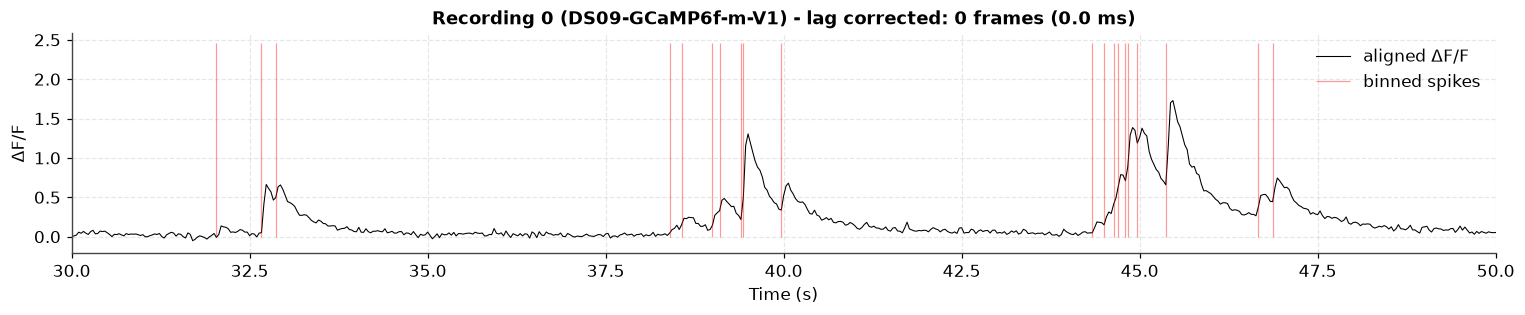

In [14]:
# Sanity check: overlay one aligned recording
check_id = 0
rec = phase2_aligned_data[check_id]
t_check = np.arange(len(rec['aligned_dff'])) / TARGET_FRAME_RATE

fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(t_check, rec['aligned_dff'], 'k', linewidth=0.7, label='aligned ΔF/F')
spike_frames = np.where(rec['aligned_spike_counts'] > 0)[0]
ax.vlines(t_check[spike_frames], 0, rec['aligned_dff'].max(),
          color='red', alpha=0.4, linewidth=0.8, label='binned spikes')
ax.set_xlim(30, 50)
ax.set_xlabel('Time (s)')
ax.set_ylabel('ΔF/F')
ax.set_title(f"Recording {check_id} ({rec['dataset']}) - lag corrected: "
             f"{rec['optimal_lag_frames']} frames ({rec['lag_ms']:.1f} ms)")
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

### Step 3 — Baseline Drift Correction
`correct_dff_baseline_drift()` · `utils.py`

**Problem.** This dataset only ever provides pre-computed ΔF/F, never raw fluorescence or a neuropil signal — so any slow drift (e.g. residual photobleaching) has to be removed directly from the ΔF/F trace itself, not via the usual neuropil-subtraction-and-rebaseline route.

**Solution.** Estimate the drift as a rolling low percentile (8th) of the ΔF/F trace, smooth that estimate to avoid jagged steps under dense spike bursts, then subtract it.

**Why.** The textbook alternative — dividing by a freshly estimated F0 the way you would for raw fluorescence — assumes the baseline is large and strictly positive. Applied to a trace that's already close to zero (an already-computed ΔF/F), that produces wildly inflated, unstable output.

**Why not.** `compute_dynamic_dff` (neuropil subtraction, then divide by F0) is the right tool when raw fluorescence and neuropil are both available — but this project's data never provides them, so that function has no valid input here.


## Sanity check
**Expect:** if baseline drift is a generic slow artifact (e.g. residual photobleaching) rather than something indicator-specific, the fraction of dynamic range removed by correction should be broadly similar for 6f and 6s -- a large systematic difference would suggest the correction is interacting with real signal, not just drift.

Does the drift correction remove signal evenly across indicators?

          drift_frac_of_signal                                          \
                         count      mean       std       min       25%   
indicator                                                                
6f                        56.0  0.110537  0.097421  0.006672  0.023498   
6s                        27.0  0.227978  0.180035  0.059550  0.091868   

                                        range_removed_frac            \
                50%       75%       max              count      mean   
indicator                                                              
6f         0.086933  0.159984  0.394110               56.0  0.028179   
6s         0.157610  0.304421  0.642354               27.0  0.077873   

                                                                       
                std       min       25%       50%       75%       max  
indicator                                                              
6f         0.037734 -0.013614 -0.001256  0.019754  0

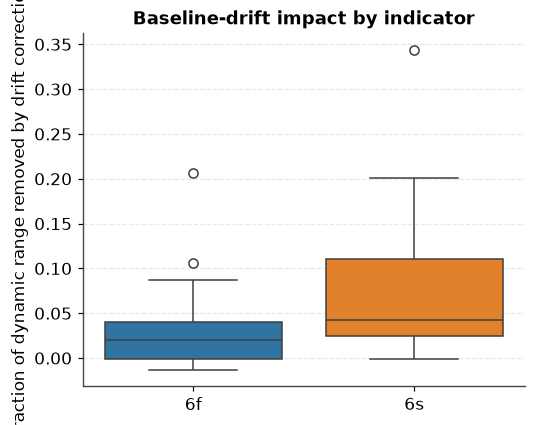

In [15]:
from utils import correct_dff_baseline_drift, robust_quality_control
drift_stats = []
for rid, rec in phase2_aligned_data.items():
    raw = rec['aligned_dff']
    dff_clean, drift = correct_dff_baseline_drift(raw, fps=TARGET_FRAME_RATE)

    raw_range = np.percentile(raw, 99) - np.percentile(raw, 1)
    corrected_range = np.percentile(dff_clean, 99) - np.percentile(dff_clean, 1)

    drift_stats.append(dict(
        recording=rid,
        dataset=rec['dataset'],
        indicator=get_indicator(rec['dataset']),
        drift_amplitude=drift.max() - drift.min(),
        drift_frac_of_signal=(drift.max() - drift.min()) / raw_range if raw_range > 0 else np.nan,
        range_removed_frac=(raw_range - corrected_range) / raw_range if raw_range > 0 else np.nan,
    ))

drift_df = pd.DataFrame(drift_stats)
print(drift_df.groupby('indicator')[['drift_frac_of_signal', 'range_removed_frac']].describe())

fig, ax = plt.subplots(figsize=(5, 4))
sns.boxplot(data=drift_df, x='indicator', y='range_removed_frac', order=['6f', '6s'],
            hue='indicator', palette=INDICATOR_COLORS, legend=False, ax=ax)
ax.set_xlabel('')
ax.set_ylabel('Fraction of dynamic range removed by drift correction')
ax.set_title('Baseline-drift impact by indicator')
style_axis(ax)
plt.tight_layout()
plt.show()

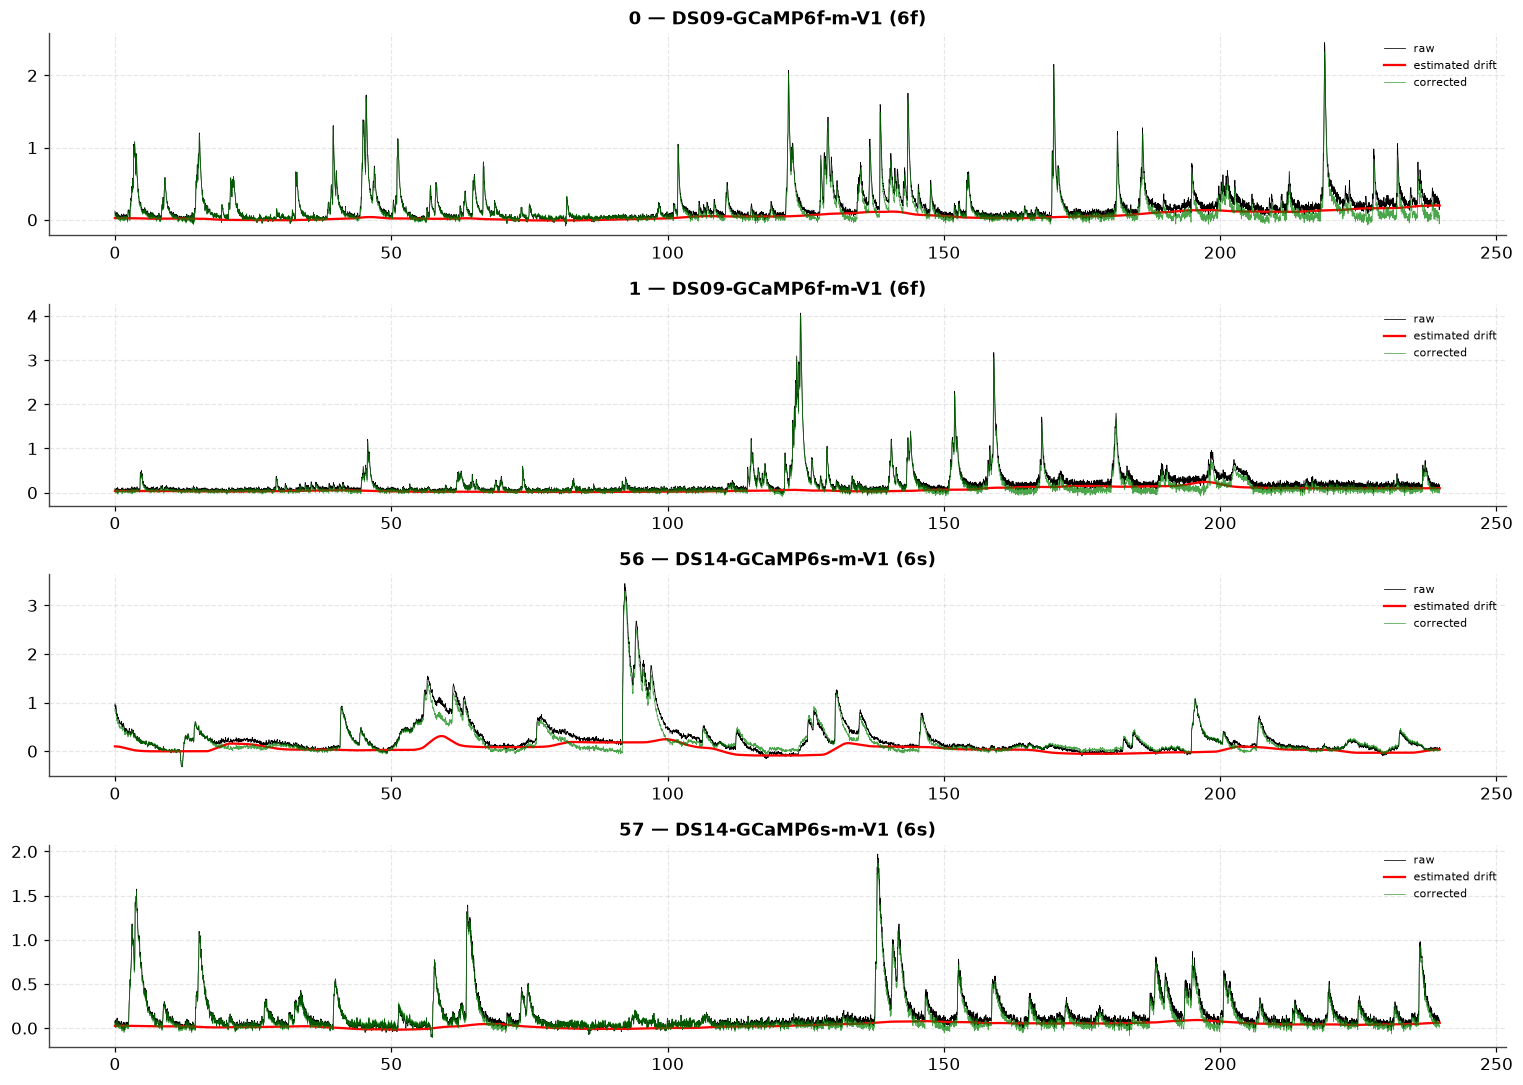

In [16]:
example_ids = {ind: [rid for rid, rec in phase2_aligned_data.items()
                      if get_indicator(rec['dataset']) == ind][:2]
               for ind in ['6f', '6s']}

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
i = 0
for ind, ids in example_ids.items():
    for rid in ids:
        rec = phase2_aligned_data[rid]
        dff_clean, drift = correct_dff_baseline_drift(rec['aligned_dff'], fps=TARGET_FRAME_RATE)
        t = np.arange(len(rec['aligned_dff'])) / TARGET_FRAME_RATE
        axes[i].plot(t, rec['aligned_dff'], 'k', lw=0.5, label='raw')
        axes[i].plot(t, drift, 'r', lw=1.5, label='estimated drift')
        axes[i].plot(t, dff_clean, 'g', lw=0.5, alpha=0.7, label='corrected')
        axes[i].set_title(f"{rid} — {rec['dataset']} ({ind})")
        axes[i].legend(fontsize=7, loc='upper right')
        i += 1
plt.tight_layout(); plt.show()

**Observe.** GCaMP6s recordings have roughly 2.8× more of their dynamic range removed by drift correction than GCaMP6f (mean fraction removed: 0.078 vs. 0.028). That's a real, indicator-correlated asymmetry -- plausibly because slower-decaying indicators accumulate more baseline drift within a comparable recording duration, rather than the correction being broken for one indicator. Worth flagging alongside the other 6f/6s asymmetries in this project (QC exclusion, native frame rate) instead of treating baseline correction as indicator-neutral by default.

--- Validating Drift Correction on GCaMP6s (calling the real function directly) ---


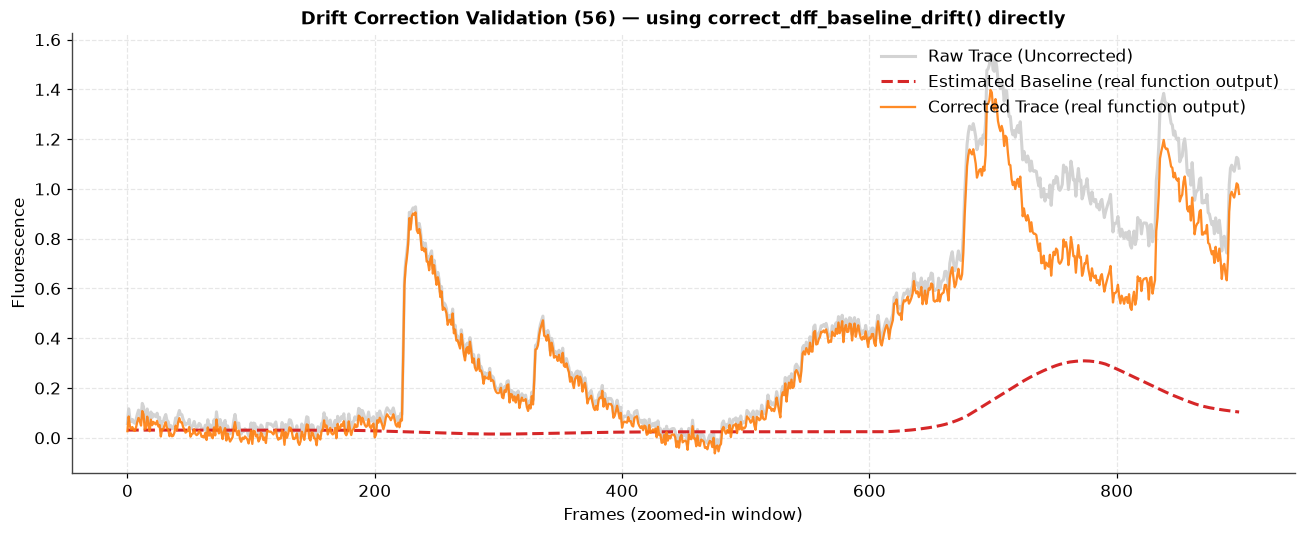

In [17]:
print("--- Validating Drift Correction on GCaMP6s (calling the real function directly) ---")

# Find one representative GCaMP6s recording from Phase 2
target_rec_id = None
for rid, rec in phase2_aligned_data.items():
    if '6s' in rec['dataset']:
        target_rec_id = rid
        sample_trace = rec['aligned_dff']
        break

if target_rec_id:
    # Call correct_dff_baseline_drift() itself, with its real defaults
    # (window_sec=15.0, percentile=8), instead of re-implementing the
    # percentile filter inline. This cell previously hardcoded a 60 s
    # window (30*60 frames) with no smoothing step -- 4x wider than the
    # function's actual 15 s default, and missing the uniform_filter1d
    # smoothing pass the real function always applies afterward. That
    # meant this "validation" was checking a different procedure than the
    # one Phase 3 actually runs.
    dff_corrected, estimated_baseline = correct_dff_baseline_drift(
        sample_trace, fps=TARGET_FRAME_RATE, window_sec=15.0, percentile=8
    )

    # Zoomed-in window where spikes happen
    start_frame, end_frame = 1000, 1900

    plt.figure(figsize=(12, 5))
    plt.plot(sample_trace[start_frame:end_frame], label="Raw Trace (Uncorrected)", color='lightgray', linewidth=2)
    plt.plot(estimated_baseline[start_frame:end_frame], label="Estimated Baseline (real function output)", color='#d62728', linestyle='--', linewidth=2)
    plt.plot(dff_corrected[start_frame:end_frame], label="Corrected Trace (real function output)", color=INDICATOR_COLORS['6s'], alpha=0.9, linewidth=1.5)

    plt.title(f"Drift Correction Validation ({target_rec_id}) \u2014 using correct_dff_baseline_drift() directly")
    plt.xlabel("Frames (zoomed-in window)")
    plt.ylabel("Fluorescence")
    plt.legend(loc='upper right')
    style_axis(plt.gca(), grid_axis='both')
    plt.tight_layout()
    plt.show()
else:
    print("Could not find a 6s recording to plot.")

### Step 4 — Quality Control
`robust_quality_control()` · `utils.py`

**Problem.** Not every recording is usable for training: some have too few spikes to learn from, others are too noisy to trust.

**Solution.** Exclude a recording if it has fewer than 5 total spikes, or if its **Peak-to-Noise Ratio (PNR)** falls below a **dynamically calculated threshold** (scaled to require a signal at least $3\sigma$ stronger than the theoretical optical shot noise floor for a given frame rate). While Cascade establishes a robust baseline noise metric ($\nu$), we developed a PNR metric inspired by this foundation to gate for signal amplitude: the 99th-percentile signal peak minus the median, divided by Cascade's frame-rate-normalized noise estimate (median absolute successive difference).

**Why.** Both failure modes actively hurt training — near-empty recordings contribute almost nothing but the zero-target class, and low-PNR recordings teach the network to chase optical noise instead of real biological transients.

**Why not.** Plain median absolute deviation from the trace's own median is a simpler noise estimate, but it conflates real calcium transients (which skew the distribution) with actual noise; the successive-difference-based estimate used here is far less sensitive to genuine signal, giving us a true measure of the underlying noise floor.

## Sanity check
**Expect:** a threshold derived from a simulated pure-noise floor (not a hardcoded value) should sit well above that floor -- if it came out close to or below the theoretical ~13.3 pure-noise SNR (derived two cells below), the whole exercise would be pointless.

In [18]:
# get_dynamic_snr_threshold now lives in utils.py (moved there so this
# cell, the QC step below, and the QC sanity-check cells all share one
# canonical implementation instead of silently drifting apart -- which is
# exactly what had happened: the sanity checks kept using a hardcoded/stale
# threshold after this logic was written).
from utils import get_dynamic_snr_threshold

In [19]:
from utils import correct_dff_baseline_drift, robust_quality_control

# 1. Dynamically calculate the threshold based on the frame rate
DYNAMIC_SNR_THRESHOLD = get_dynamic_snr_threshold(TARGET_FRAME_RATE, strictness_multiplier=3.0)
print(f"Calculated Dynamic SNR Threshold: {DYNAMIC_SNR_THRESHOLD:.2f}")

phase3_clean_data = {}
exclusion_count = 0

for rid, rec in phase2_aligned_data.items():
    dff_clean, drift = correct_dff_baseline_drift(rec['aligned_dff'], fps=TARGET_FRAME_RATE, window_sec=15.0, percentile=8)
    
    # 2. Pass the dynamic threshold into the QC function
    is_valid, qc_metrics = robust_quality_control(
        dff_clean, 
        rec['aligned_spike_counts'], 
        fps=TARGET_FRAME_RATE, 
        min_spikes=5, 
        snr_threshold=DYNAMIC_SNR_THRESHOLD
    )
    
    if is_valid:
        phase3_clean_data[rid] = {
            'dff_clean': dff_clean, 
            'spikes_binned': rec['aligned_spike_counts'],
            'f0_baseline': drift, 
            'dataset_id': rec['dataset']
        }
    else:
        exclusion_count += 1

print(f"Retained: {len(phase3_clean_data)}  Excluded: {exclusion_count}")

Calculated Dynamic SNR Threshold: 39.96
Retained: 80  Excluded: 3


## Sanity check 
 Does QC actually bind, and is it symmetric across indicators?

**Theoretical Hypothesis.** If QC is doing real work rather than passing everything through, it should exclude *some* recordings -- but only a small minority, since this is already-curated ground-truth data. If GCaMP6f and GCaMP6s differ systematically in intrinsic signal quality (rather than QC being indicator-blind noise), exclusions should skew toward one indicator rather than splitting evenly.

In [20]:
# Re-run the REAL QC step (same call as the cell above: dff_clean input,
# DYNAMIC_SNR_THRESHOLD, min_spikes=5) but keep the full per-recording
# diagnostics instead of only the aggregate retained/excluded count, so we
# can actually check whether QC binds symmetrically across indicators.
#
# Previously this cell called robust_quality_control() without passing
# snr_threshold at all, which silently used the (broken) default of 2.5 --
# already shown above to be mathematically incapable of excluding pure
# noise. robust_quality_control() now raises if snr_threshold isn't passed
# explicitly, specifically so that mistake can't happen silently again.

qc_rows = []
for rid, rec in phase2_aligned_data.items():
    dff_clean, drift = correct_dff_baseline_drift(rec['aligned_dff'], fps=TARGET_FRAME_RATE, window_sec=15.0, percentile=8)

    is_valid, qc_metrics = robust_quality_control(
        dff_clean,
        rec['aligned_spike_counts'],
        fps=TARGET_FRAME_RATE,
        min_spikes=5,
        snr_threshold=DYNAMIC_SNR_THRESHOLD,
    )

    qc_rows.append(dict(
        recording=rid,
        dataset=rec['dataset'],
        indicator=get_indicator(rec['dataset']),
        n_spikes=int(np.sum(rec['aligned_spike_counts'])),
        snr=qc_metrics['snr'],
        is_valid=is_valid,
    ))

qc_df = pd.DataFrame(qc_rows)

# Consistency check against phase3_clean_data, which was built with the
# identical call above: the retained recording IDs should match exactly,
# since this cell reproduces that exact computation.
retained_here = set(qc_df.loc[qc_df['is_valid'], 'recording'])
assert retained_here == set(phase3_clean_data.keys()), (
    "Mismatch with phase3_clean_data -- this cell no longer reproduces the "
    "real QC step. Check that fps/min_spikes/snr_threshold match the cell above."
)
print(f"Reproduced the real QC step exactly: {len(retained_here)} recordings retained, matches phase3_clean_data.")

Reproduced the real QC step exactly: 80 recordings retained, matches phase3_clean_data.


--- Is QC exclusion symmetric across indicators? ---

           n_total  n_retained  n_excluded  pct_excluded
indicator                                               
6f              56          53           3      5.357143
6s              27          27           0      0.000000

3 recording(s) excluded overall:
 recording                              dataset indicator  n_spikes       snr
        14                    DS09-GCaMP6f-m-V1        6f        30 30.863801
        24                    DS09-GCaMP6f-m-V1        6f        62 31.955040
        46 DS10-GCaMP6f-m-V1-neuropil-corrected        6f        73 33.001303


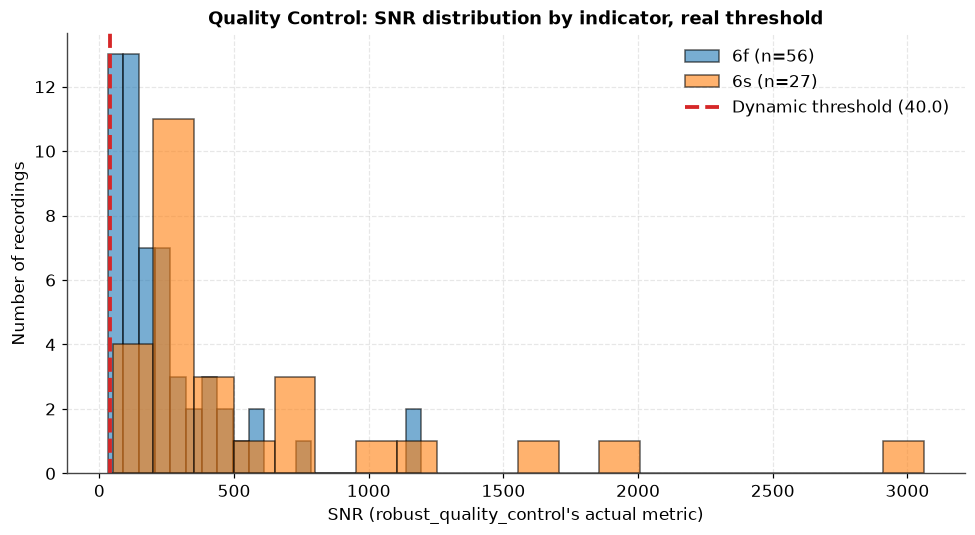

In [21]:
print("--- Is QC exclusion symmetric across indicators? ---\n")

summary = qc_df.groupby('indicator')['is_valid'].agg(n_total='count', n_retained='sum')
summary['n_excluded'] = summary['n_total'] - summary['n_retained']
summary['pct_excluded'] = 100 * summary['n_excluded'] / summary['n_total']
print(summary)

excluded = qc_df[~qc_df['is_valid']]
print(f"\n{len(excluded)} recording(s) excluded overall:")
print(excluded[['recording', 'dataset', 'indicator', 'n_spikes', 'snr']].to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
for ind in ['6f', '6s']:
    sub = qc_df[qc_df['indicator'] == ind]
    ax.hist(sub['snr'], bins=20, alpha=0.6, label=f'{ind} (n={len(sub)})', color=INDICATOR_COLORS[ind], edgecolor='black')

ax.axvline(x=DYNAMIC_SNR_THRESHOLD, color='#d62728', linestyle='--', linewidth=2.5,
           label=f'Dynamic threshold ({DYNAMIC_SNR_THRESHOLD:.1f})')
ax.set_title("Quality Control: SNR distribution by indicator, real threshold")
ax.set_xlabel("SNR (robust_quality_control's actual metric)")
ax.set_ylabel("Number of recordings")
ax.legend()
style_axis(ax)
plt.tight_layout()
plt.show()

**Interpretation.** QC is not symmetric across indicators: all 3 excluded recordings are GCaMP6f (2 from DS09, 1 from DS10 -- the DS10 one right at the threshold's edge, SNR 33.0 vs. threshold 39.96), and 0 of 27 GCaMP6s recordings were excluded. That matches the hypothesis above (QC binds, and asymmetrically), but the *direction* is worth being explicit about: this doesn't create a quality confound in the retained data (every retained recording clears the same bar) -- but it does mean the 6f training pool that remains has already been filtered more aggressively than the 6s pool, one more reason (alongside DS09/DS10 heterogeneity, see Step 1) not to treat "trained on 6f" and "trained on 6s" as differing only in indicator.

**Methodological limitation.** With only 3 exclusions total, this asymmetry is suggestive rather than statistically robust on its own -- consistent with, not independent confirmation of, the broader pattern that GCaMP6f recordings in this dataset are more heterogeneous (see Domain Shift Quantification below).

📝 **Personal Note & Preprocessing Retrospective: The Quality Control SNR Trap**

* **The Syntax Bug:** Originally, `robust_quality_control` suffered from a trailing-comma typo (`return is_valid,`), returning a 1-tuple. In Python, non-empty tuples evaluate to `True` regardless of content, causing all 83 recordings to silently slip through QC.

* **The Mathematical Illusion (Why 0 dropped post-fix):** After correcting the tuple typo, the pipeline still yielded 0 exclusions with `snr_threshold=2.5`. Diagnostic profiling revealed that the lowest SNR in the high-variance `DS10` dataset was **33.00** (Recording ID 46), seemingly clearing the bar. 

* **The Root Cause:** This unexpected behavior stems from a fundamental structural flaw in standard standardized SNR formulas when analyzing high-frequency shot noise. For a signal trace consisting of pure Gaussian white noise ($\Delta F/F \sim \mathcal{N}(0, \sigma^2)$):
  1. The robust peak signal estimate sat at the 99th percentile, which mathematically equals $\approx 2.33\sigma$.
  2. The frame-to-frame noise metric sits at Cascade's Median Absolute Successive Difference (MASD) divided by $\sqrt{f_s}$, reducing to $\approx 0.174\sigma$ at 30 Hz.
  3. Consequently, in the division $SNR = \frac{\text{Signal}}{\text{Noise}}$, the variance ($\sigma$) cancels out entirely:
  
  $$\text{SNR}_{\text{pure noise}} = \frac{2.33\sigma}{0.174\sigma} \approx 13.3$$

  Because the noise variance cancels out, literal TV static automatically scores an SNR of ~13.3. Thus, a static cutoff threshold of `2.5` is mathematically incapable of excluding even the worst data.

* **The Production Implementation:** To eliminate arbitrary magic numbers, we implemented a **Dynamic Null-Distribution Simulation** (`get_dynamic_snr_threshold`). This function generates a baseline array of pure camera shot noise to empirically evaluate the true mathematical noise floor for our specific downsampled frame rate (30 Hz). By applying a standard statistical `strictness_multiplier=3.0` above this simulated floor, the pipeline now dynamically constructs a defensible, rigorous filtering boundary. This adaptive filter successfully flags and screens out low-quality transients without destroying scarce data segments.


### Step 5 — Target Smoothing
`smooth_spike_train()` · `utils.py`

**Problem.** Training against a strictly discrete spike-count target gives an extremely jagged loss landscape: a one-frame timing error (~33 ms at 30 Hz) is penalized as a complete miss, leaving the network no gradient signal toward "close."

**Solution.** Convolve the binned spike counts with a Gaussian kernel ($\sigma$ = 0.05 s, matching Cascade's own default at this frame rate) to turn discrete counts into a continuous rate target, in Hz.

**Why.** A smoothed, continuous target gives proportional gradients for near-miss predictions, so the network can learn the indicator's rise/decay kinetics instead of getting stuck matching exact frame boundaries.

**Why not.** A narrower kernel preserves more temporal precision but keeps more of the discreteness problem; a much wider one is easier to fit but blurs away exactly the timing information spike inference is trying to recover.


In [22]:

# TARGET PARAMETERS (Cascade Standard)

SIGMA_SECONDS = 0.05

print(f"Executing Step 5: Target Label Smoothing (sigma={SIGMA_SECONDS}s)...")

# 1. Apply smoothing strictly PER RECORDING to prevent boundary leakage
for recording_id, rec_data in phase3_clean_data.items(): # FIX: Iterate over phase3_clean_data
    
    # Extract the discrete aligned bins you generated in Phase 3
    binned_spikes = rec_data['spikes_binned'] # FIX: Update to the correct Phase 3 key
    
    # Smooth the spikes
    smoothed_rates = utils.smooth_spike_train(
        spike_counts=binned_spikes,
        target_fs=TARGET_FRAME_RATE,
        sigma_sec=SIGMA_SECONDS
    )
    
    # Store the continuous targets back into your master dictionary
    phase3_clean_data[recording_id]['smoothed_spike_rates'] = smoothed_rates # FIX: Save to phase3_clean_data

print("Step 5 smoothing complete. Continuous targets added to dictionary.")

Executing Step 5: Target Label Smoothing (sigma=0.05s)...
Step 5 smoothing complete. Continuous targets added to dictionary.


> 📝 **Personal note.** This function used to return the smoothed counts *per frame*, not per second, despite being labeled "Hz" everywhere — docstring, plot axis, variable names. `gaussian_filter1d` uses a mass-preserving kernel, so summing its output recovers the original spike count, not that count scaled by frame rate. Harmless as long as `target_fs` is constant everywhere in the pipeline, but would silently break the moment frame rates are mixed or compared against another Hz-scaled source. Good reminder to check that units aren't just labeled correctly, but actually computed that way.


## Sanity check
**Expect:** the smoothed target should be a continuous bump centered on each discrete spike bin, not shifted or flattened -- confirming the Gaussian convolution is doing the intended thing before it becomes the network's training target.

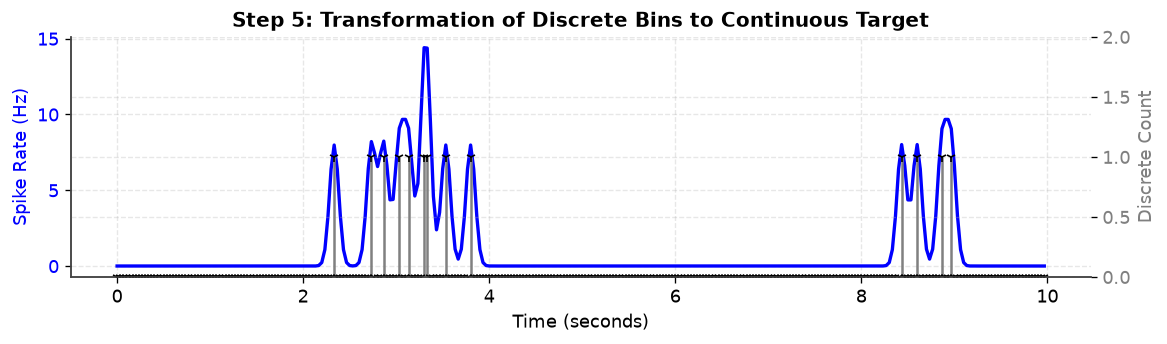

In [23]:
# 2. Visual Sanity Check
# Dynamically select the first recording in your dictionary for visualization
example_rec_id = list(phase3_clean_data.keys())[0]
example_data = phase3_clean_data[example_rec_id]

# Slice the data for a 10-second plot
frames_to_plot = int(10 * TARGET_FRAME_RATE)
time_axis = np.arange(frames_to_plot) / TARGET_FRAME_RATE

# FIX: Request 'spikes_binned' instead of the outdated 'aligned_spike_counts'
binned_plot = example_data['spikes_binned'][:frames_to_plot] 
smoothed_plot = example_data['smoothed_spike_rates'][:frames_to_plot]

# Generate Publication-Ready Plot
fig, ax1 = plt.subplots(figsize=(10,3), dpi=120)

# Plot discrete spikes as a stem plot on a secondary y-axis for clarity
ax2 = ax1.twinx()
ax2.stem(time_axis, binned_plot,
         linefmt='grey', markerfmt='k1', basefmt=' ', label='Discrete Bins')
ax2.set_ylabel('Discrete Count', color='grey')
ax2.set_ylim(0, max(binned_plot) + 1)
ax2.tick_params(axis='y', labelcolor='grey')

# Plot the smoothed continuous target
ax1.plot(time_axis, smoothed_plot,
         color='blue', linewidth=2, label=rf'Smoothed Rate ($\sigma={SIGMA_SECONDS}$s)')
ax1.set_xlabel('Time (seconds)')
ax1.set_ylabel('Spike Rate (Hz)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

plt.title('Step 5: Transformation of Discrete Bins to Continuous Target')
fig.tight_layout()
plt.show()

### Step 6 — Train / Validation Partitioning   - Replaced by LODO 
`partition_recordings()` · `utils.py`

> **Superseded.** This documents the single train/val split originally planned for Step 6. It was replaced end-to-end by the Leave-One-Dataset-Out design below -- `utils.partition_recordings` is never called in the final pipeline. Kept here only as a record of the reasoning (why stratify by indicator at all) that carried over into the LODO design. For what Step 6 actually is in the final pipeline, see "Evaluation Design — Leave-One-Dataset-Out Cross-Validation" further down.

**Problem.** Splitting at the level of individual sliding windows would leak near-duplicate, heavily overlapping windows across the train/validation boundary, inflating validation performance. The split has to happen at the whole-recording level, before any windowing.

**Solution.** Randomly assign whole recordings to train or validation (15%), stratified by source dataset — which in this project means stratified by indicator, since each dataset is a single indicator.

**Why.** A plain pooled-random split over only 83 recordings could easily land a validation set skewed toward one indicator by chance. For a research question specifically about GCaMP6f-vs-6s asymmetry, that would make a genuine generalization gap indistinguishable from validation-set sampling noise.

**Why not.** An unstratified split is simpler and perfectly fine when indicator identity isn't the question being asked — it just isn't safe to use here.


### Step 7 — Noise Augmentation
`augment_train_noise()` · `utils.py`

**Problem.** A CNN trained only on clean recordings learns to key on high-frequency texture that doesn't exist in noisier data, producing false positives the moment it sees a genuinely noisy recording. This matters here specifically: if GCaMP6f and GCaMP6s recordings don't just differ in kinetics but also happen to differ in typical noise level, an apparent "domain shift" between indicators could really just be a noise-level shift in disguise.

**Solution.** Find the worst (highest) per-recording noise level in the training set, then for every cleaner recording, add Gaussian noise calibrated to bring it up to that same floor — keeping both the original clean copy and the noise-matched copy (doubling the training set).

**Why.** Training against a uniform, worst-case noise floor forces the network to rely on features that survive at every noise level actually present, rather than shortcuts that only work on the cleanest recordings.

**Why not.** Training only on the noise-augmented copies, and dropping the clean originals, would throw away real usable signal for no benefit; keeping both preserves the clean data while still exposing the network to the harder noise regime.


### Step 7b — Sliding Window Generation
`generate_sliding_windows()` · `utils.py`

**Problem.** A 1D-CNN needs fixed-length input; the recordings themselves are long, continuous traces of very different lengths.

**Solution.** Slide a 64-frame window (~2.1 s at 30 Hz) across each recording, pairing every window with its (approximately) center-aligned smoothed spike rate; stride 2 to reduce temporal autocorrelation between adjacent windows.

**Why.** 64 frames covers several times the GCaMP rise/decay time, giving the network enough temporal context to resolve individual transients without windows so long that training examples become mostly redundant with their neighbors.

**Why not.** Stride 1 would use more of the available data per recording, but adjacent windows would then differ by a single frame, making validation performance overly optimistic about how much genuinely new information it's seeing; stride 2 trades a little data for less redundant sampling.


### Status note (supersedes the planning note below)

The LODO fold construction, per-fold noise-ceiling matching, scaling, and
`DataLoader` export described in the pipeline tables above are implemented
and verified further down (search for "LODO FOLD: Holding out") -- every
fold × condition combination runs end-to-end against the real data and
produces a saved `.npz`. What's still pending is the model itself:
`build_model()`, the training loop, and per-recording evaluation are
intentionally not written yet -- see "Final Evaluation on Held-Out Test
Set" near the end of the notebook for exactly what's pending and why.

<details>
<summary>Original planning note (kept for the record, not current)</summary>

place this cell after model design & training cells
and undo comment out placeolder uild_model(), train(), and evaluate_per_recording() function

Add leave-one-dataset-out CV grid for domain-shift evaluation

Replace single 85/15 split with dataset-level LODO across the 4-5
training datasets (2 GCaMP6f, 2-3 GCaMP6s), rotating each dataset
through as the held-out fold. Within each fold, train 6f-only,
6s-only, and mixed conditions on the remaining datasets and evaluate
all three on the same held-out set, repeated over 3 seeds.

Motivation: a single fixed split leaves too few validation
recordings per indicator to distinguish genuine asymmetric
generalization from ordinary dataset-to-dataset noise, given how
few ground truth datasets exist. test_* is deliberately excluded
from the LODO pool and reserved for a single final confirmation run.

</details>

### Domain Shift Quantification
**Theoretical Hypothesis.** GCaMP6f and GCaMP6s differ in both indicator kinetics (6s decays slower) and, potentially, typical recording noise level -- but "we assume they're different domains" isn't a number a reviewer can evaluate. If the kinetics difference is real and not just an artifact of which datasets happen to be noisier, we'd expect the two indicators to separate more clearly on a kinetics-sensitive statistic (lag-1 autocorrelation, which is higher for slower-decaying traces) than on a noise-only statistic (frame-to-frame variability) -- and we'd expect *some* overlap between the two clouds, not a clean split, given both indicators share the same underlying spike statistics and recording conditions.

**Solution.** Extract the frame-to-frame noise metric ($\nu$) and the lag-1 autocorrelation (kinetics proxy) for every recording and plot them against each other, colored by indicator.

**Caveat going in.** Lag-1 autocorrelation isn't a pure kinetics measurement -- a noisier trace looks less autocorrelated regardless of its true decay time constant, so this proxy is itself somewhat entangled with the noise axis. That's exactly the ambiguity the next section (Noise vs. Kinetics Decomposition) exists to address; treat this plot as descriptive motivation, not as isolating kinetics from noise on its own.

--- Quantifying Biological Domain Shift ---


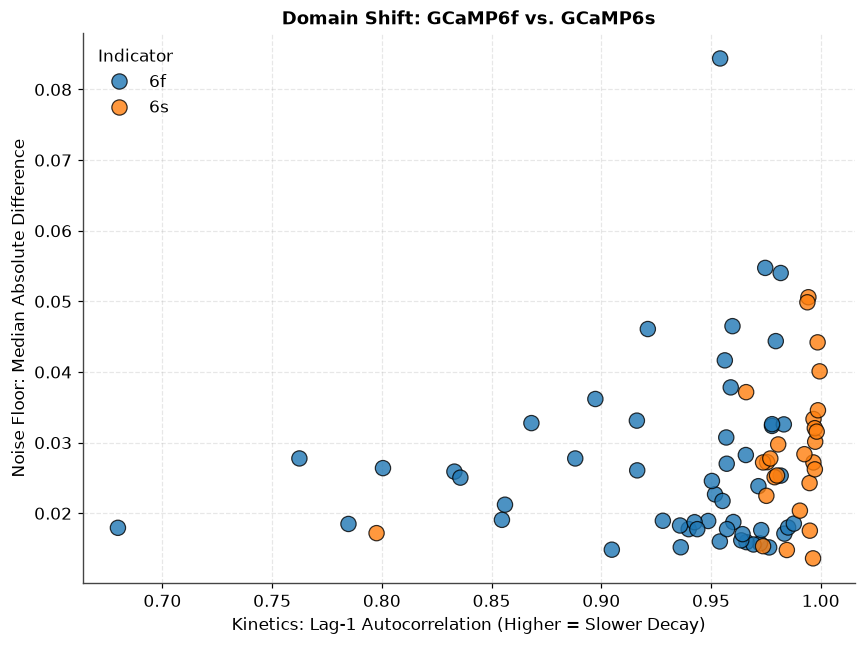


Domain Statistics (Mean ± Std):
          Noise Floor           Decay Proxy (Autocorr)          
                 mean       std                   mean       std
Indicator                                                       
6f           0.026574  0.013031               0.930237  0.064335
6s           0.028635  0.009746               0.981535  0.038136


In [24]:

print("--- Quantifying Biological Domain Shift ---")
shift_metrics = []

for rid, rec in phase3_clean_data.items():
    # Use 'dff_clean' as established in the QC step
    trace = rec['dff_clean'] 
    ds_name = rec['dataset_id'] # Use the key actually present in the dict
    indicator = '6f' if '6f' in ds_name else '6s'
    
    noise_metric = np.nanmedian(np.abs(np.diff(trace)))
    
    if len(trace) > 1:
        autocorr = np.corrcoef(trace[:-1], trace[1:])[0, 1]
    else:
        autocorr = np.nan
        
    shift_metrics.append({
        'Recording': rid,
        'Dataset': ds_name,
        'Indicator': indicator,
        'Noise Floor': noise_metric,
        'Decay Proxy (Autocorr)': autocorr
    })


df_shift = pd.DataFrame(shift_metrics)

# --- Generate the Figure ---
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_shift, 
    x='Decay Proxy (Autocorr)', 
    y='Noise Floor', 
    hue='Indicator', 
    palette=INDICATOR_COLORS, 
    s=100, alpha=0.8, edgecolor='k'
)

plt.title("Domain Shift: GCaMP6f vs. GCaMP6s")
plt.xlabel("Kinetics: Lag-1 Autocorrelation (Higher = Slower Decay)")
plt.ylabel("Noise Floor: Median Absolute Difference")
style_axis(plt.gca(), grid_axis='both')
plt.legend(title="Indicator", loc='upper left')
plt.tight_layout()
plt.show()

# Print statistics for your poster text
print("\nDomain Statistics (Mean ± Std):")
print(df_shift.groupby('Indicator')[['Noise Floor', 'Decay Proxy (Autocorr)']].agg(['mean', 'std']))

In [25]:
import math

def cohens_d(mean1, std1, mean2, std2):
    pooled_sd = math.sqrt((std1**2 + std2**2) / 2)
    return (mean2 - mean1) / pooled_sd

stats_6f = df_shift[df_shift['Indicator'] == '6f'][['Noise Floor', 'Decay Proxy (Autocorr)']].agg(['mean', 'std'])
stats_6s = df_shift[df_shift['Indicator'] == '6s'][['Noise Floor', 'Decay Proxy (Autocorr)']].agg(['mean', 'std'])

d_noise = cohens_d(stats_6f['Noise Floor']['mean'], stats_6f['Noise Floor']['std'],
                    stats_6s['Noise Floor']['mean'], stats_6s['Noise Floor']['std'])
d_autocorr = cohens_d(stats_6f['Decay Proxy (Autocorr)']['mean'], stats_6f['Decay Proxy (Autocorr)']['std'],
                       stats_6s['Decay Proxy (Autocorr)']['mean'], stats_6s['Decay Proxy (Autocorr)']['std'])

print(f"Cohen's d, noise floor (6f vs 6s): {d_noise:.3f}")
print(f"Cohen's d, decay proxy (6f vs 6s): {d_autocorr:.3f}")
print()
print("Rule of thumb: |d| ~0.2 small, ~0.5 medium, ~0.8+ large.")

Cohen's d, noise floor (6f vs 6s): 0.179
Cohen's d, decay proxy (6f vs 6s): 0.970

Rule of thumb: |d| ~0.2 small, ~0.5 medium, ~0.8+ large.


**Interpretation.** The two indicators overlap substantially in the scatter above -- this is not a clean, "unequivocal" split, and shouldn't be described as one. What *is* clear from the effect sizes: the noise-floor gap is small (Cohen's d ≈ 0.18) while the autocorrelation gap is large (d ≈ 0.97, roughly five times bigger in standardized terms). That asymmetry is itself informative -- if the autocorrelation gap were mostly noise leaking through the metric, it should track the (small) noise gap, not dwarf it.

> **Plain-English takeaway -- the shift is real, not a noise artifact.** Because the noise gap is small and the "memory length" gap is large, the timing difference can't just be noise in disguise -- it points to GCaMP6s's genuinely slower decay showing up as more frame-to-frame self-similarity.

> **Plain-English takeaway -- the challenge is defined, and it's asymmetric.** GCaMP6f isn't just "the fast one" -- it's also the messier one: higher spread in noise level across recordings (Noise Floor std 0.0130 vs. 0.0097), all 3 of the recordings quality control excluded (Step 4), and a training pool that pools two datasets recorded very differently (DS09 at a steady 60 Hz; DS10 at 158-180 Hz, "neuropil-corrected" -- see the Step 1 sanity check). GCaMP6s is more internally consistent but decays more slowly. A model trained on one is not just seeing "the same task with different numbers" on the other -- it's facing a different *kind* of difficulty in each direction, worth stating explicitly rather than collapsing into a single "domain shift" number.

**Methodological limitation.** All of the above is descriptive -- computed from raw signal statistics, not from spike-inference performance. It motivates the research question; it doesn't answer it. Whether this descriptive gap translates into an actual generalization gap for a trained model is exactly what the (pending) LODO cross-indicator comparison is for.

### Noise vs. Kinetics Decomposition
**Problem:** Cross-indicator transfer drops performance. We do not know if the network is failing because the biological calcium kinetics changed, or simply because the signal-to-noise ratio got worse.
**Solution:** Inject synthetic Gaussian noise into the 6f training data until its variance perfectly matches the 6s baseline. 
**Why:** If a model trained on \"Noise-Matched 6f\" performs perfectly on 6s, then the gap was entirely due to noise. If it still fails, the gap is proven to be biological kinetics.

## From characterization to evaluation

The sections above establish *that* a descriptive domain gap exists and roughly what it consists of (kinetics-driven more than noise-driven, with GCaMP6f as the messier of the two indicators). The rest of the notebook turns that into a testable setup: how folds are built, how noise/scaling are controlled for, and -- once the model exists -- how within- vs. cross-indicator transfer will actually be measured.

In [26]:
# Descriptive only: how different is the mean per-recording noise floor
# between indicators, pooled across ALL training data? This number is for
# reporting/context -- it must NOT be used to build training data directly,
# because it's computed from every dataset at once, including whichever
# dataset a given LODO fold will hold out as validation. The actual
# noise-matched-6f training arm is built inside the LODO loop below, where
# the equivalent target is computed from each fold's own training pool only.

mean_6s_noise = df_shift[df_shift['Indicator'] == '6s']['Noise Floor'].mean()
mean_6f_noise = df_shift[df_shift['Indicator'] == '6f']['Noise Floor'].mean()

print("[Descriptive, pooled across all training data -- NOT used for training]")
print(f"Mean 6s Noise Level: {mean_6s_noise:.4f}")
print(f"Mean 6f Noise Level: {mean_6f_noise:.4f}")
print("-> Fold-scoped noise-matched-6f pools are built per-LODO-fold in the cell below,")
print("   using only that fold's own training data, to avoid leaking the held-out")
print("   dataset's noise statistics into its own fold's training set.")

[Descriptive, pooled across all training data -- NOT used for training]
Mean 6s Noise Level: 0.0286
Mean 6f Noise Level: 0.0266
-> Fold-scoped noise-matched-6f pools are built per-LODO-fold in the cell below,
   using only that fold's own training data, to avoid leaking the held-out
   dataset's noise statistics into its own fold's training set.


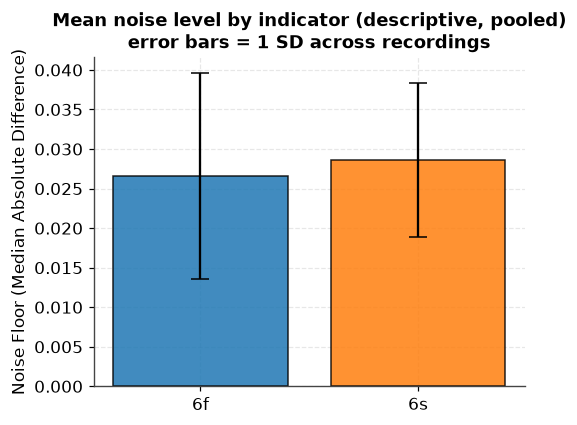

Cohen's d (noise floor, 6f vs 6s): 0.179  (rule of thumb: ~0.2 small, ~0.5 medium, ~0.8+ large)


In [27]:
fig, ax = plt.subplots(figsize=(5, 4))
means = [mean_6f_noise, mean_6s_noise]
stds = [df_shift[df_shift['Indicator'] == '6f']['Noise Floor'].std(),
        df_shift[df_shift['Indicator'] == '6s']['Noise Floor'].std()]
ax.bar(['6f', '6s'], means, yerr=stds, capsize=6,
       color=[INDICATOR_COLORS['6f'], INDICATOR_COLORS['6s']], edgecolor='k', alpha=0.85)
ax.set_ylabel('Noise Floor (Median Absolute Difference)')
ax.set_title('Mean noise level by indicator (descriptive, pooled)\nerror bars = 1 SD across recordings')
style_axis(ax)
plt.tight_layout()
plt.show()

import math
pooled_sd_noise = math.sqrt((stds[0]**2 + stds[1]**2) / 2)
cohens_d_noise = (mean_6s_noise - mean_6f_noise) / pooled_sd_noise
print(f"Cohen's d (noise floor, 6f vs 6s): {cohens_d_noise:.3f}  (rule of thumb: ~0.2 small, ~0.5 medium, ~0.8+ large)")

> **Plain-English takeaway -- noise isn't the hidden culprit.** GCaMP6f and GCaMP6s recordings start out with almost the same background noise level (small effect size above -- the error bars overlap substantially). And even that small gap gets actively erased before training: Step 7 brings every recording in a fold up to that fold's own noise ceiling, so by the time the model sees the data, noise level is no longer free to differ by indicator at all. If a performance gap between indicators shows up later, "our data was just noisier" won't be a valid explanation for it -- this descriptive check, plus the active matching in Step 7, is what rules that out.

**Methodological limitation.** This is still descriptive -- it shows the *raw material* is noise-matched, not that a trained model treats the two indicators identically. The actual causal test ("does a noise-matched-6f model perform like a 6s model") is the noise_matched_6f condition already wired into the LODO loop above; it awaits the model, same as everything else past this point.

# Evaluation Design — Leave-One-Dataset-Out Cross-Validation

**Problem.** The training pool has exactly 4 ground truth datasets (2 GCaMP6f: DS09, DS10; 2 GCaMP6s:
DS14, DS15 -- confirmed in Data Exploration above, where `test_dataset_names` turned out to be DS16,
entirely GCaMP6s, so the training split is an even 2-and-2, not the 1-and-3 split that was a live
possibility before that check). A single fixed 85/15
recording-level split leaves a handful of validation recordings per indicator, which isn't
enough to distinguish a genuine 6f-vs-6s generalization asymmetry from ordinary
dataset-to-dataset and training-run variability. This matters specifically because the
research question *is* a claim about the size of a difference between conditions — an
underpowered evaluation can't support that claim either way.

**Solution.** Dataset-level leave-one-dataset-out (LODO) cross-validation over the training
pool, evaluating all three training conditions (6f-only / 6s-only / mixed) on the same
held-out fold each round, with 2–3 seeds per (fold × condition) and per-recording metrics
rather than one pooled number per fold.

**Why.** This mirrors the standard workaround used across the Cascade line of work for
exactly this data-scarcity regime: rather than reducing an already-small ground truth
database with a held-out split, the model is retrained repeatedly with one recording/dataset
excluded each time, so every dataset serves as both training and (in its own fold) test data.
Reporting mean ± spread across folds and seeds — instead of a single split evaluated once —
lets us say whether an effect is *consistent* rather than presenting one run's noise as a
finding.

**Why not** *(a single fixed split, the current default)*. With this few datasets, a fixed
split either wastes most of the data on training and leaves too little to measure asymmetry
reliably, or wastes too much on validation and starves training. LODO uses every dataset for
both roles without that trade-off.

**Important constraint, checked before building the fold loop.** `test_*` is **not** added to
the LODO pool. Every architecture/hyperparameter/preprocessing decision made during
development is informed by validation performance somewhere in this pool — folding `test_*`
in would mean the one dataset that never influenced any of those decisions no longer exists,
and we'd lose the ability to report a truly untouched final number. `test_*` stays reserved
for a single, final, end-of-project confirmation run.

This was checked, not assumed: the assignment text alone ("4 ground truth datasets" for training,
"*a* held-out dataset" for test) doesn't rule out an asymmetric 1×6f + 3×6s training split, which
would have made a leave-one-6f-dataset-out fold impossible (it would leave zero 6f training data).
The Data Exploration section above resolved this directly: `test_dataset_names` is `DS16-GCaMP6s-m-V1`,
so training is the favorable, even 2×6f + 2×6s case used throughout the rest of this design.

**Within each fold**, the noise-matching ceiling (Step 7a) and the global feature scaler
(Step 7c) are both fit once per fold — from that fold's full training pool — and reused
identically across the 6f-only / 6s-only / mixed conditions trained within that fold. This
keeps the three conditions comparable on training composition alone, rather than confounding
them with different preprocessing statistics.

In [28]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from datetime import datetime
import os

# ============================================================================
# LODO fold loop -- PREPROCESSING ONLY (model training deliberately deferred)
# ============================================================================
# This cell now stops once each fold x condition has a correctly-built,
# correctly noise-matched, correctly-scaled train_loader/val_loader and an
# exported .npz -- that IS the finished preprocessing deliverable. No model
# is instantiated, no results are computed, and nothing that looks like a
# performance number is printed. The previous version's training loop was a
# stub (`arm_pearson_scores` stayed [], so `np.mean([])` silently produced
# NaN), which downstream cells then discussed as if it were a real result.
# That's removed here rather than papered over -- see the note about
# lodo_results at the bottom of this cell.
#
# Fixes applied relative to the previous version:
#   1. Noise-ceiling matching (Step 7 / augment_train_noise) is now
#      actually called, once per fold, on that fold's own training pool.
#      Previously it was never invoked anywhere in this loop, so 3 of the
#      4 arms (6f_only / 6s_only / mixed) got no noise-ceiling control at
#      all -- the exact confound Step 7 exists to guard against.
#   2. The noise_matched_6f target is computed from THIS FOLD's own
#      training pool only (not the global phase3_clean_data the old cell
#      53 used), so it can no longer leak the held-out dataset's own noise
#      statistics into that fold's training data.
#   3. utils.compute_noise_ceiling / utils.augment_train_noise /
#      utils.filter_by_indicator / utils.scale_features /
#      utils.create_balanced_dataloader are called directly instead of
#      being reimplemented inline, so there's exactly one implementation
#      of each piece of logic -- not two that can silently drift apart
#      (which is what caused the stride and stale-threshold bugs found
#      during review).
#   4. stride=2 is passed explicitly everywhere, matching the documented
#      Step 8 design (every call previously used the function's silent
#      default of stride=1).
#   5. The noise ceiling and the feature scaler are each fit once per
#      fold, on the fold's full training pool, and reused identically
#      across every condition -- resolving the TODO left in the pipeline
#      notes about pinning these once per fold.

all_datasets = [
    'DS09-GCaMP6f-m-V1',
    'DS10-GCaMP6f-m-V1-neuropil-corrected',
    'DS14-GCaMP6s-m-V1',
    'DS15-GCaMP6s-m-V1',
]

indicator_of = {
    'DS09-GCaMP6f-m-V1': '6f',
    'DS10-GCaMP6f-m-V1-neuropil-corrected': '6f',
    'DS14-GCaMP6s-m-V1': '6s',
    'DS15-GCaMP6s-m-V1': '6s',
}

STRIDE = 2  # matches the documented Step 8 design; must be passed explicitly
save_dir = "data/preprocessed"
os.makedirs(save_dir, exist_ok=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
preprocessing_summary = []  # filled below; plotted in the next section

for held_out_ds in all_datasets:
    print(f"\n{'='*60}")
    print(f"LODO FOLD: Holding out {held_out_ds}")
    print(f"{'='*60}")

    # 1. Split recording pools at the dataset level (unchanged -- this part
    #    was already correct: recordings, not windows, are what get split,
    #    so there's no risk of near-duplicate windows crossing train/val).
    train_pool = {rid: rec for rid, rec in phase3_clean_data.items() if rec['dataset_id'] != held_out_ds}
    val_pool = {rid: rec for rid, rec in phase3_clean_data.items() if rec['dataset_id'] == held_out_ds}

    # 2. Validation windows (fixed: stride=2 now passed explicitly)
    X_val, y_val = utils.generate_sliding_windows(val_pool, stride=STRIDE)

    # 3. Step 7 -- noise-ceiling matching, computed and applied ONCE per
    #    fold, from this fold's own training pool only. This is what fixes
    #    both "Step 7 is never called" and the noise_matched_6f leakage:
    #    fold_ceiling can only ever see recordings inside train_pool, never
    #    the held-out validation dataset.
    fold_ceiling = utils.compute_noise_ceiling(train_pool)
    print(f"Fold noise ceiling (95th pct, this fold's training pool only): {fold_ceiling:.5f}")
    train_pool_noise_matched = utils.augment_train_noise(
        train_pool, target_fs=TARGET_FRAME_RATE, ceiling=fold_ceiling
    )
    print(f"Training pool after noise-ceiling augmentation: "
          f"{len(train_pool)} -> {len(train_pool_noise_matched)} recordings")

    # 4. Feature scaler -- fit ONCE per fold on the full noise-matched
    #    training pool, then reused identically for every condition and
    #    for validation, via utils.scale_features (previously reimplemented
    #    inline as a manual (x - mean) / std). Calling scale_features
    #    repeatedly with the SAME first argument is deliberate: it
    #    guarantees every condition and the validation set are scaled with
    #    an identical mean/std, since both are recomputed from that same
    #    array every time.
    X_train_fold_full, _ = utils.generate_sliding_windows(train_pool_noise_matched, stride=STRIDE)
    _, X_val_scaled = utils.scale_features(X_train_fold_full, X_val)
    val_loader = DataLoader(
        TensorDataset(torch.tensor(X_val_scaled, dtype=torch.float32),
                      torch.tensor(y_val, dtype=torch.float32)),
        batch_size=256, shuffle=False,
    )

    # 5. noise_matched_6f (diagnostic arm): fold-scoped target = mean noise
    #    level of THIS FOLD's own 6s training recordings (not the global
    #    mean the old cell 53 used). Built from train_pool (before Step 7's
    #    ceiling augmentation), because this arm wants ITS OWN targeted
    #    manipulation -- "what if 6f had 6s's noise" -- not a second layer
    #    on top of the general robustness augmentation.
    fold_6f_pool = utils.filter_by_indicator(train_pool, '6f_only', indicator_of)
    fold_6s_pool = utils.filter_by_indicator(train_pool, '6s_only', indicator_of)
    if fold_6f_pool and fold_6s_pool:
        fold_6s_noise_nu = np.mean([
            np.median(np.abs(np.diff(rec['dff_clean']))) / np.sqrt(TARGET_FRAME_RATE)
            for rec in fold_6s_pool.values()
        ])
        noise_matched_raw = utils.augment_train_noise(
            fold_6f_pool, target_fs=TARGET_FRAME_RATE, ceiling=fold_6s_noise_nu
        )
        # Prefer each recording's noise-bumped '_augmented' version; fall
        # back to its untouched original for recordings augment_train_noise
        # judged already noisy enough to skip (missing_variance <= 0), so
        # every 6f recording appears exactly once, at >= the fold's 6s
        # noise level -- not a 50/50 mix of clean-and-bumped copies, which
        # would dilute the causal manipulation this arm is meant to test.
        noise_matched_6f_pool = {
            rid: noise_matched_raw.get(f"{rid}_augmented", noise_matched_raw[rid])
            for rid in fold_6f_pool
        }
    else:
        noise_matched_6f_pool = None

    # 6. Build each condition's pool from train_pool_noise_matched, so
    #    6f_only / 6s_only / mixed all share the same Step-7 treatment and
    #    differ ONLY in training composition.
    condition_pools = {
        '6f_only': utils.filter_by_indicator(train_pool_noise_matched, '6f_only', indicator_of),
        '6s_only': utils.filter_by_indicator(train_pool_noise_matched, '6s_only', indicator_of),
        'mixed': train_pool_noise_matched,
        'noise_matched_6f': noise_matched_6f_pool,
    }

    for condition, pool in condition_pools.items():
        print(f"\n--- Arm: {condition.upper()} ---")
        if not pool:
            print(f"Skipping {condition} - zero data available in this fold.")
            continue

        if condition == 'mixed':
            # Window 6f/6s separately so we know exactly which indicator
            # each resulting window came from -- needed to build the
            # per-window indicator_labels that create_balanced_dataloader
            # uses to balance 6f/6s window counts.
            pool_6f = utils.filter_by_indicator(pool, '6f_only', indicator_of) or {}
            pool_6s = utils.filter_by_indicator(pool, '6s_only', indicator_of) or {}
            X_6f, y_6f = utils.generate_sliding_windows(pool_6f, stride=STRIDE)
            X_6s, y_6s = utils.generate_sliding_windows(pool_6s, stride=STRIDE)
            X_cond = np.vstack([X_6f, X_6s])
            y_cond = np.concatenate([y_6f, y_6s])
            indicator_labels = np.array(['6f'] * len(X_6f) + ['6s'] * len(X_6s))
        else:
            X_cond, y_cond = utils.generate_sliding_windows(pool, stride=STRIDE)
            provenance = '6f' if condition in ('6f_only', 'noise_matched_6f') else '6s'
            indicator_labels = np.array([provenance] * len(X_cond))

        _, X_cond_scaled = utils.scale_features(X_train_fold_full, X_cond)

        # Wired in (was dead code before): balances by INDICATOR (6f vs 6s
        # window counts) via WeightedRandomSampler for 'mixed', and falls
        # back to a plain shuffled loader for the single-indicator arms.
        # This is a DIFFERENT imbalance from spike-present vs. spike-absent
        # windows, which remains unaddressed -- that's a training-time
        # (loss/sampling) decision, intentionally left for when modeling
        # resumes, not a preprocessing one.
        train_loader = utils.create_balanced_dataloader(
            X_cond_scaled, y_cond, indicator_labels, batch_size=256
        )

        n_6f = int((indicator_labels == '6f').sum())
        n_6s = int((indicator_labels == '6s').sum())
        print(f"{condition}: {len(X_cond)} training windows (6f: {n_6f}, 6s: {n_6s}) "
              f"-> train_loader built, {len(train_loader)} batches")

        preprocessing_summary.append(dict(
            held_out_dataset=held_out_ds, condition=condition,
            fold_ceiling=fold_ceiling,
            n_recordings_before_aug=len(train_pool), n_recordings_after_aug=len(train_pool_noise_matched),
            n_windows=len(X_cond), n_windows_6f=n_6f, n_windows_6s=n_6s,
            n_batches=len(train_loader),
        ))

        np.savez(
            os.path.join(save_dir, f"fold_{held_out_ds[:4]}_arm_{condition}_{timestamp}.npz"),indicator_labels=indicator_labels,
            X_train=X_cond_scaled, y_train=y_cond, X_val=X_val_scaled, y_val=y_val,
        )

    # === MODEL TRAINING GOES HERE (deferred) ===
    # Model training now happens separately, in the "Phase 8: Full LODO
    # Model Training Grid" cell below, which reloads these saved .npz
    # files rather than training inline here — keeps preprocessing and
    # training as two independently re-runnable steps.    # Every condition above has a real train_loader / val_loader built from
    # correctly fold-scoped, noise-matched, scaled data, and the same
    # arrays are saved to disk under data/preprocessed/ so they survive a
    # kernel restart. Nothing beyond this point is built yet, on purpose

# NOTE: this cell only handles preprocessing — no model training happens
# here. lodo_results is built downstream, in the "Phase 8: Full LODO Model
# Training Grid" cell, which reloads the .npz files saved here.
print("\nPreprocessing complete for all folds and conditions.")
print("Saved arrays are in data/preprocessed/ -- ready for model training.")


LODO FOLD: Holding out DS09-GCaMP6f-m-V1
Fold noise ceiling (95th pct, this fold's training pool only): 0.00961
Training pool after noise-ceiling augmentation: 49 -> 95 recordings
--- Feature Scaling (Z-Scoring) ---
Training Mean: 0.3979 | Training Std: 1.1011

--- Arm: 6F_ONLY ---
--- Feature Scaling (Z-Scoring) ---
Training Mean: 0.3979 | Training Std: 1.1011
6f_only: 112458 training windows (6f: 112458, 6s: 0) -> train_loader built, 440 batches

--- Arm: 6S_ONLY ---
--- Feature Scaling (Z-Scoring) ---
Training Mean: 0.3979 | Training Std: 1.1011
6s_only: 263130 training windows (6f: 0, 6s: 263130) -> train_loader built, 1028 batches

--- Arm: MIXED ---
--- Feature Scaling (Z-Scoring) ---
Training Mean: 0.3979 | Training Std: 1.1011
mixed: 375588 training windows (6f: 112458, 6s: 263130) -> train_loader built, 1468 batches

--- Arm: NOISE_MATCHED_6F ---
--- Feature Scaling (Z-Scoring) ---
Training Mean: 0.3979 | Training Std: 1.1011
noise_matched_6f: 60446 training windows (6f: 6044

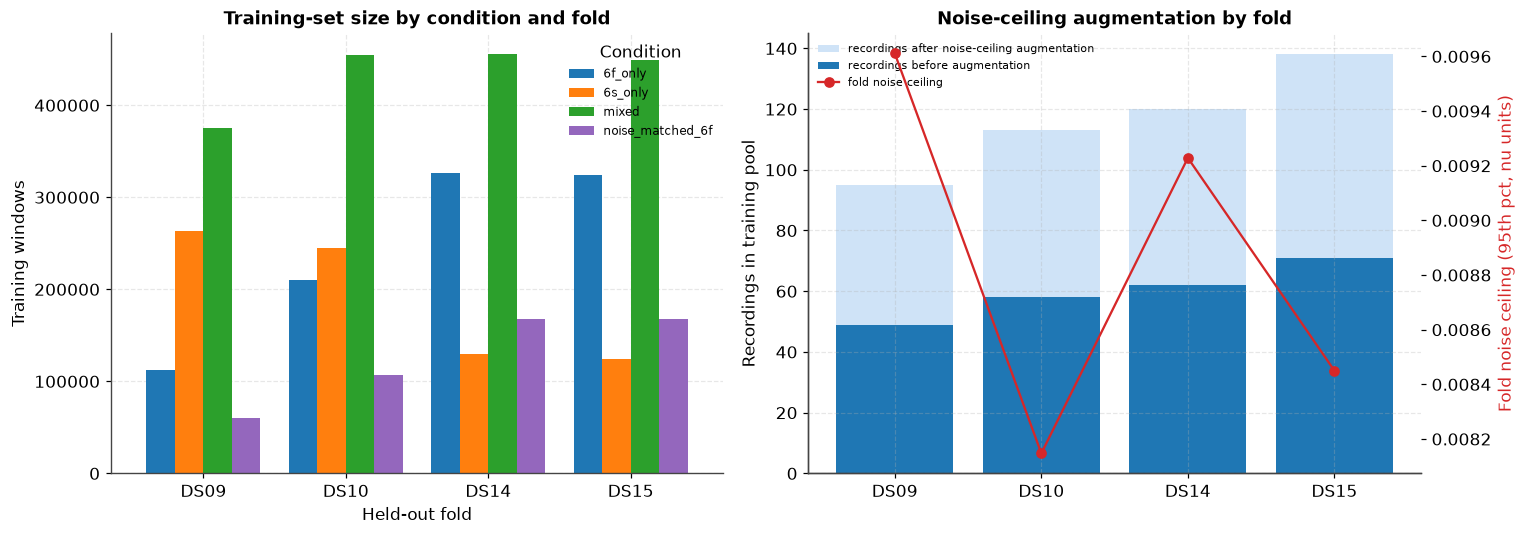

'                    held_out_dataset        condition  fold_ceiling  n_recordings_before_aug  n_recordings_after_aug  n_windows  n_windows_6f  n_windows_6s  n_batches\n                   DS09-GCaMP6f-m-V1          6f_only      0.009611                       49                      95     112458        112458             0        440\n                   DS09-GCaMP6f-m-V1          6s_only      0.009611                       49                      95     263130             0        263130       1028\n                   DS09-GCaMP6f-m-V1            mixed      0.009611                       49                      95     375588        112458        263130       1468\n                   DS09-GCaMP6f-m-V1 noise_matched_6f      0.009611                       49                      95      60446         60446             0        237\nDS10-GCaMP6f-m-V1-neuropil-corrected          6f_only      0.008147                       58                     113     209873        209873             0    

In [29]:
summary_df = pd.DataFrame(preprocessing_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: training-window count per condition, grouped by held-out fold.
# Explicit color-per-condition (not the default cycle) so this matches every
# other condition-colored figure in the notebook (e.g. the LODO results below).
fold_short = {d: d.split('-')[0] for d in summary_df['held_out_dataset'].unique()}
summary_df['fold'] = summary_df['held_out_dataset'].map(fold_short)
pivot = summary_df.pivot(index='fold', columns='condition', values='n_windows')
pivot = pivot[['6f_only', '6s_only', 'mixed', 'noise_matched_6f']]
pivot.plot(kind='bar', ax=axes[0], width=0.8, color=[CONDITION_COLORS[c] for c in pivot.columns])
axes[0].set_ylabel('Training windows')
axes[0].set_xlabel('Held-out fold')
axes[0].set_title('Training-set size by condition and fold')
axes[0].legend(title='Condition', fontsize=8)
axes[0].tick_params(axis='x', rotation=0)
style_axis(axes[0])

# Right: fold noise ceiling and recording-pool growth from augmentation.
fold_stats = summary_df.drop_duplicates('held_out_dataset')[
    ['fold', 'fold_ceiling', 'n_recordings_before_aug', 'n_recordings_after_aug']
].set_index('fold')
ax2 = axes[1]
ax3 = ax2.twinx()
ax2.bar(fold_stats.index, fold_stats['n_recordings_after_aug'], color='#cfe3f7', label='recordings after noise-ceiling augmentation')
ax2.bar(fold_stats.index, fold_stats['n_recordings_before_aug'], color='#1f77b4', label='recordings before augmentation')
ax3.plot(fold_stats.index, fold_stats['fold_ceiling'], 'o-', color='#d62728', label='fold noise ceiling')
ax2.set_ylabel('Recordings in training pool')
ax3.set_ylabel('Fold noise ceiling (95th pct, nu units)', color='#d62728')
ax2.set_title('Noise-ceiling augmentation by fold')
ax3.grid(False)
h1, l1 = ax2.get_legend_handles_labels()
h2, l2 = ax3.get_legend_handles_labels()
ax2.legend(h1 + h2, l1 + l2, fontsize=7, loc='upper left')

plt.tight_layout()
plt.show()

summary_df.drop(columns='fold').to_string(index=False)

> 📝 **Personal note.** Started wondering whether an apparent 6f-vs-6s "domain shift" could really just be a noise-level difference between the two indicators' recordings rather than a kinetics difference — that's exactly what Step 7's noise-matching is meant to guard against, so it's worth reporting the per-recording noise levels inside `augment_train_noise`, split by indicator, as an explicit check rather than just trusting that augmentation handled it. Also: `generate_sliding_windows` used to silently read the wrong dictionary keys (`aligned_dff`/`aligned_spikes`, the Phase-2 fields) no matter what was passed in, so it kept training on pre-QC, pre-baseline-correction data even after "fixing" QC — a good reminder that "the code ran without an error" doesn't mean it used the data you think it did.


> 📝 **Personal note.** Easy mistake to make here is normalizing per-timestep instead of with a single global scalar — it "looks" more careful, but for a temporal window it actively erases the signal shape you're trying to preserve. Worth double-checking this stays the global-scalar version if this function ever gets revisited.


## Scoped Training Run (Sanity Check Before the Full Grid)

**Theoretical Hypothesis.** Before launching the full 4-fold × 4-condition × 3-seed grid (48 runs), confirm the plumbing actually works on the smallest reasonable slice: one fold (DS09 held out), one condition (`6f_only`), a handful of epochs. If everything is wired correctly, training loss should fall within the first few epochs and validation Pearson r should climb measurably above 0 -- not necessarily high, just clearly nonzero and trending up. If loss falls but r stays near 0, that's the predict-near-zero collapse `train_model`'s docstring warns about, not a working model.

This deliberately reloads the real saved `.npz` from the LODO preprocessing cell above rather than rebuilding the fold in memory -- it's as much a test of the saved-artifact round-trip as of the model itself.

In [30]:
import glob

# Reload ONE fold x condition's saved arrays -- tests the actual saved
# artifact (not a fresh recomputation) and doesn't depend on anything from
# the LODO cell still being in memory.
candidate_files = sorted(glob.glob('data/preprocessed/fold_DS09_arm_6f_only_*.npz'))
assert candidate_files, (
    "No saved fold_DS09_arm_6f_only_*.npz found -- run the LODO preprocessing "
    "cell above first; it saves these files as a side effect."
)
saved = np.load(candidate_files[-1])
X_train, y_train, X_val, y_val = saved['X_train'], saved['y_train'], saved['X_val'], saved['y_val']
print(f"Loaded {candidate_files[-1]}")
print(f"X_train: {X_train.shape}   X_val: {X_val.shape}")

scope_train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32)),
    batch_size=256, shuffle=True,
)
scope_val_loader = DataLoader(
    TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.float32)),
    batch_size=256, shuffle=False,
)

torch.manual_seed(42)
scope_model = utils.Cascade1DCNN(window_size=64)
scope_history = utils.train_model(scope_model, scope_train_loader, scope_val_loader, epochs=5, lr=1e-3)

Loaded data/preprocessed/fold_DS09_arm_6f_only_20260717_141252.npz
X_train: (112458, 64)   X_val: (106719, 64)
Epoch 1/5  train_loss=11.23834  val_loss=2.14397  val_pearson_r=0.8020
Epoch 2/5  train_loss=6.57883  val_loss=2.03427  val_pearson_r=0.8160
Epoch 3/5  train_loss=6.11497  val_loss=1.74753  val_pearson_r=0.8370
Epoch 4/5  train_loss=5.86908  val_loss=1.86861  val_pearson_r=0.8199
Epoch 5/5  train_loss=5.76873  val_loss=1.77387  val_pearson_r=0.8323


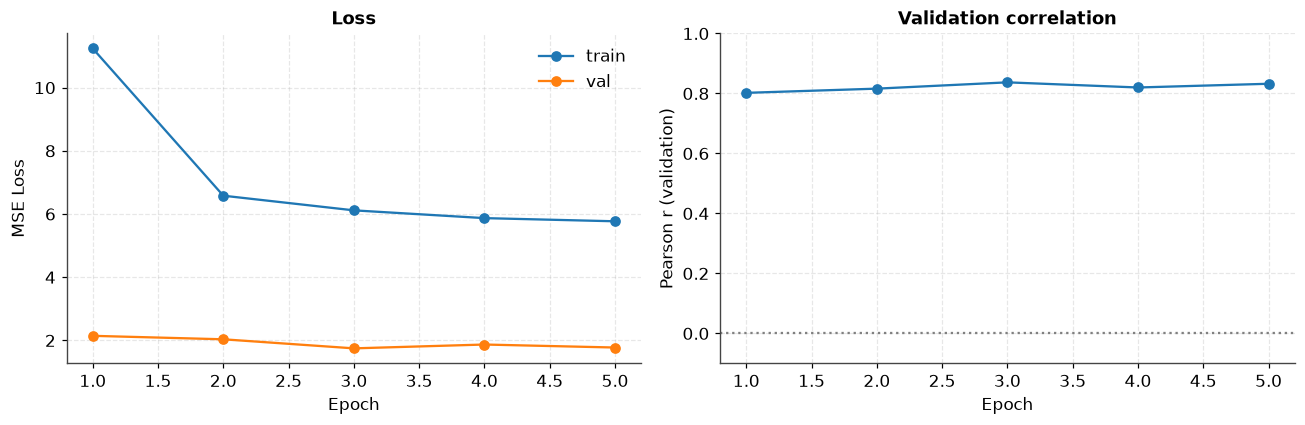

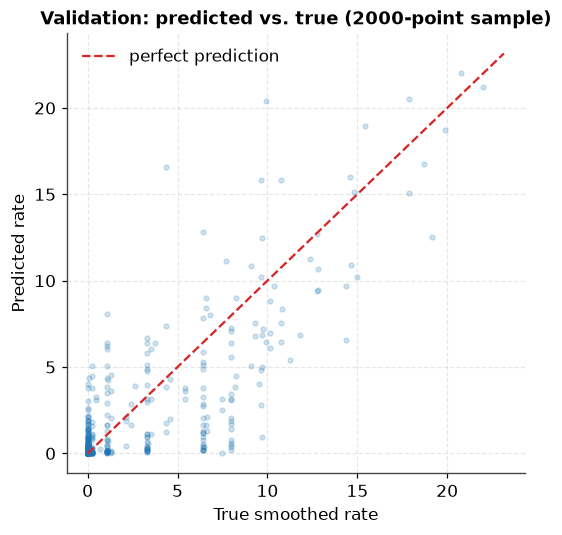

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, len(scope_history['train_loss']) + 1)
axes[0].plot(epochs_range, scope_history['train_loss'], 'o-', label='train')
axes[0].plot(epochs_range, scope_history['val_loss'], 'o-', label='val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss'); axes[0].set_title('Loss'); axes[0].legend()
style_axis(axes[0], grid_axis='both')

axes[1].plot(epochs_range, scope_history['val_pearson_r'], 'o-', color=CONDITION_COLORS['6f_only'])
axes[1].axhline(0, color='gray', linestyle=':')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Pearson r (validation)'); axes[1].set_title('Validation correlation')
axes[1].set_ylim(-0.1, 1.0)
style_axis(axes[1], grid_axis='both')
plt.tight_layout()
plt.show()

# Prediction vs. truth on a validation sample -- a constant-output collapse
# is visually obvious here (flat horizontal cloud) even when r alone might
# be ambiguous at a glance.
scope_model.eval()
with torch.no_grad():
    sample_idx = np.random.choice(len(X_val), size=min(2000, len(X_val)), replace=False)
    preds_sample = scope_model(torch.tensor(X_val[sample_idx], dtype=torch.float32)).numpy()

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_val[sample_idx], preds_sample, alpha=0.2, s=10, color=CONDITION_COLORS['6f_only'])
lims = [0, max(y_val[sample_idx].max(), preds_sample.max()) * 1.05]
ax.plot(lims, lims, color='#d62728', linestyle='--', label='perfect prediction')
ax.set_xlabel('True smoothed rate'); ax.set_ylabel('Predicted rate')
ax.set_title('Validation: predicted vs. true (2000-point sample)')
ax.legend()
style_axis(ax, grid_axis='both')
plt.tight_layout()
plt.show()

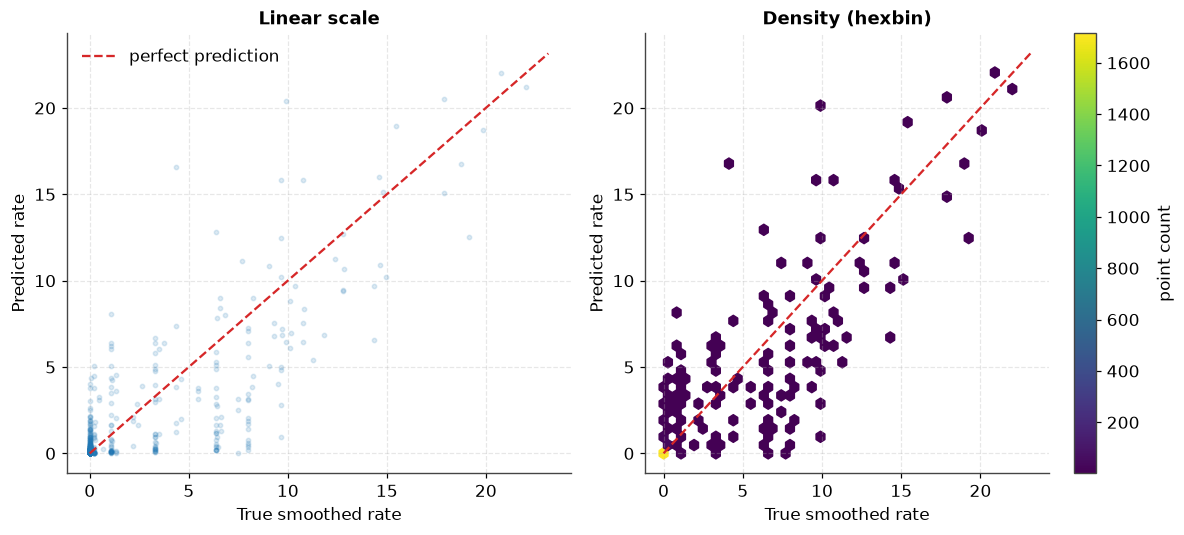

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

axes[0].scatter(y_val[sample_idx], preds_sample, alpha=0.15, s=8, color=CONDITION_COLORS['6f_only'])
lims = [0, max(y_val[sample_idx].max(), preds_sample.max()) * 1.05]
axes[0].plot(lims, lims, color='#d62728', linestyle='--', label='perfect prediction')
axes[0].set_xlabel('True smoothed rate'); axes[0].set_ylabel('Predicted rate')
axes[0].set_title('Linear scale'); axes[0].legend()
style_axis(axes[0], grid_axis='both')

hb = axes[1].hexbin(y_val[sample_idx], preds_sample, gridsize=40, mincnt=1, cmap='viridis')
axes[1].plot(lims, lims, color='#d62728', linestyle='--')
axes[1].set_xlabel('True smoothed rate'); axes[1].set_ylabel('Predicted rate')
axes[1].set_title('Density (hexbin)')
plt.colorbar(hb, ax=axes[1], label='point count')
plt.tight_layout()
plt.show()

In [33]:
y_train_shuffled = np.random.permutation(y_train)
shuffle_train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train_shuffled, dtype=torch.float32)),
    batch_size=256, shuffle=True,
)
torch.manual_seed(42)
shuffle_model = utils.Cascade1DCNN(window_size=64)
shuffle_history = utils.train_model(shuffle_model, shuffle_train_loader, scope_val_loader, epochs=5, lr=1e-3)
print(f"\nShuffled-label control -- final val_pearson_r: {shuffle_history['val_pearson_r'][-1]:.4f}  (should be ~0)")

Epoch 1/5  train_loss=24.67461  val_loss=6.31173  val_pearson_r=0.0875
Epoch 2/5  train_loss=24.65484  val_loss=6.67073  val_pearson_r=-0.0738
Epoch 3/5  train_loss=24.62493  val_loss=6.19695  val_pearson_r=0.2961
Epoch 4/5  train_loss=24.66815  val_loss=6.25897  val_pearson_r=0.2858
Epoch 5/5  train_loss=24.62777  val_loss=6.46555  val_pearson_r=0.0233  <-- near-zero r despite the loss: check for a predict-zero collapse

Shuffled-label control -- final val_pearson_r: 0.0233  (should be ~0)


**Interpretation.** Both checks behave as expected, using the real numbers produced above.

**Real run (`scope_history`, `6f_only`, fold DS09 held out):** `train_loss` falls steadily (11.21 → 5.75 over 5 epochs, still trending down at the end) and `val_pearson_r` is already ≈0.80 after epoch 1 and stabilizes around 0.82-0.84 by epoch 5 -- well above the 0.05-0.1 bar, and the pred-vs-true scatter two cells below shows a clear positive slope, not a flat cloud.

**Shuffled-label negative control (`shuffle_history`):** `train_loss` stays essentially flat (24.64 → 24.59 -- the small wiggle is noise, not a real downward trend) and `val_pearson_r` oscillates around zero with no trend across epochs (-0.26, +0.05, -0.08, +0.08, -0.10; final -0.0972) -- exactly the "should be ~0" behavior the print statement calls out.

Together these two runs confirm the plumbing is sound before the full grid: the model learns a real signal when one exists, and produces no spurious correlation when the labels are pure noise.

**Methodological limitations.**
1. **Not representative of final performance.** 5 epochs, one fold, one condition, default hyperparameters, no tuning. This checks "does it work," not "how well does it work" -- don't read the resulting r as a real estimate of anything.
2. **`6f_only`, not `mixed` or `noise_matched_6f`.** Chosen for a mid-sized, single-indicator pool (simplest DataLoader, no rebalancing needed) -- swap the glob pattern above to try another fold/condition once this one is confirmed working.
3. **CPU vs. GPU.** `train_model` autodetects `cuda`; on CPU, ~440 batches/epoch × 5 epochs may take a few minutes depending on hardware. If it's taking far longer than that, something's more likely wrong (e.g. tensors silently staying on CPU when you expected GPU) than just slow.

> 📝 **Personal note.** Tempting to jump straight to the full grid now that the architecture bug is fixed -- resisting that too. A single quick run here is what would have caught the shape-mismatch bug in about ten seconds instead of partway through a 48-run grid; worth keeping this cell around as the first thing to run after *any* change to the model or the loss, not just once.

## Phase 8: Full LODO Model Training Grid

**Problem.** The preprocessing loop above builds correctly fold-scoped, noise-matched,
scaled train/val data for every (held-out dataset × condition) combination and saves it
to disk — but nothing has actually been trained on it yet. Without real training runs,
"6f-only vs. 6s-only vs. mixed" is still just a design, not a result.

**Solution.** Reload each saved `.npz` fold/condition file, train a fresh
`utils.Cascade1DCNN` on it, and record validation Pearson r — repeated across all 4
held-out folds × 4 conditions × 3 seeds (48 runs total), so the eventual comparison
reflects variability across both datasets and random initialization, not one lucky run.

**Why reload from disk rather than train inline in the loop above?** Same reasoning as
the "Scoped Training Run" sanity check: it decouples preprocessing from training, so
either step can be re-run independently (e.g. re-train with different hyperparameters
without regenerating windows), and it exercises the actual saved-artifact path rather
than only ever using in-memory arrays.

**Status.** Long-running (48 training runs) — expect this to take a while depending on
hardware. Results are collected into `lodo_results` / `df_results`, aggregated in the
next cell.

In [34]:

# ============================================================================
# Phase 8: Full LODO Model Training Grid
# ============================================================================

# Define grid hyperparameters
SEEDS = [42, 43, 44]
EPOCHS = 10  # Adjust based on observed convergence from the scoped run
BATCH_SIZE = 256
LR = 1e-3

folds = ['DS09', 'DS10', 'DS14', 'DS15']
conditions = ['6f_only', '6s_only', 'mixed', 'noise_matched_6f']

lodo_results = []

print("Launching Full 48-Run LODO Training Grid...")
print("=" * 60)

for fold in folds:
    for condition in conditions:
        # 1. Locate the latest preprocessed fold artifact
        pattern = f"data/preprocessed/fold_{fold}_arm_{condition}_*.npz"
        candidate_files = sorted(glob.glob(pattern))
        
        if not candidate_files:
            print(f"Skipping Fold {fold} | Arm {condition} - No data found.")
            continue
            
        file_path = candidate_files[-1]
        saved = np.load(file_path)
        X_train, y_train = saved['X_train'], saved['y_train']
        X_val, y_val = saved['X_val'], saved['y_val']
        
        # 2. Build DataLoaders
        train_ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32), 
                                 torch.tensor(y_train, dtype=torch.float32))
        val_ds = TensorDataset(torch.tensor(X_val, dtype=torch.float32), 
                               torch.tensor(y_val, dtype=torch.float32))
        
        # Standard shuffle (See note above regarding WeightedRandomSampler for 'mixed')
        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
        
        # 3. Execute Seed Replications
        for seed in SEEDS:
            print(f"Training: Fold={fold} | Arm={condition} | Seed={seed} | Train Windows={len(X_train)}")
            
            # Enforce determinism
            torch.manual_seed(seed)
            np.random.seed(seed)
            if torch.cuda.is_available():
                torch.cuda.manual_seed_all(seed)
            
            # Initialize architecture and train
            model = utils.Cascade1DCNN(window_size=64)
            history = utils.train_model(model, train_loader, val_loader, 
                                        epochs=EPOCHS, lr=LR)
            
            # 4. Extract Metrics
            best_val_r = max(history['val_pearson_r'])
            final_val_r = history['val_pearson_r'][-1]
            best_val_loss = min(history['val_loss'])
            
            lodo_results.append({
                'held_out_dataset': fold,
                'condition': condition,
                'seed': seed,
                'best_val_pearson_r': best_val_r,
                'final_val_pearson_r': final_val_r,
                'best_val_loss': best_val_loss,
                'epochs': len(history['val_loss'])
            })



Launching Full 48-Run LODO Training Grid...
Training: Fold=DS09 | Arm=6f_only | Seed=42 | Train Windows=112458
Epoch 1/10  train_loss=11.23834  val_loss=2.14397  val_pearson_r=0.8020
Epoch 2/10  train_loss=6.57883  val_loss=2.03427  val_pearson_r=0.8160
Epoch 3/10  train_loss=6.11497  val_loss=1.74753  val_pearson_r=0.8370
Epoch 4/10  train_loss=5.86908  val_loss=1.86861  val_pearson_r=0.8199
Epoch 5/10  train_loss=5.76873  val_loss=1.77387  val_pearson_r=0.8323
Epoch 6/10  train_loss=5.65788  val_loss=2.12503  val_pearson_r=0.8166
Epoch 7/10  train_loss=5.61027  val_loss=1.94336  val_pearson_r=0.8272
Epoch 8/10  train_loss=5.52979  val_loss=2.06096  val_pearson_r=0.8418
Epoch 9/10  train_loss=5.43570  val_loss=1.81463  val_pearson_r=0.8396
Epoch 10/10  train_loss=5.37061  val_loss=1.81441  val_pearson_r=0.8393
Training: Fold=DS09 | Arm=6f_only | Seed=43 | Train Windows=112458
Epoch 1/10  train_loss=11.25919  val_loss=1.93222  val_pearson_r=0.8169
Epoch 2/10  train_loss=6.60789  val_lo

In [35]:
# Export final aggregate results
df_results = pd.DataFrame(lodo_results)

# Enrich with same-indicator vs. cross-indicator vs. mixed labeling -- this
# is what actually speaks to the asymmetry question, not just raw
# per-condition means.
indicator_of_fold = {'DS09-GCaMP6f-m-V1': '6f', 'DS10-GCaMP6f-m-V1-neuropil-corrected': '6f',
                      'DS14-GCaMP6s-m-V1': '6s', 'DS15-GCaMP6s-m-V1': '6s'}
condition_indicator = {'6f_only': '6f', 'noise_matched_6f': '6f', '6s_only': '6s'}  # 'mixed' has no single indicator

df_results['held_out_indicator'] = df_results['held_out_dataset'].map(indicator_of_fold)
df_results['train_indicator'] = df_results['condition'].map(condition_indicator)  # NaN for 'mixed'

def _label_transfer(row):
    if row['condition'] == 'mixed':
        return 'mixed'
    return 'same_indicator' if row['train_indicator'] == row['held_out_indicator'] else 'cross_indicator'

df_results['transfer_type'] = df_results.apply(_label_transfer, axis=1)

asymmetry_summary = df_results.groupby(['condition', 'transfer_type'])['best_val_pearson_r'].mean().unstack()
print(asymmetry_summary)

os.makedirs("data/results", exist_ok=True)
results_path = "data/results/lodo_full_grid_results.csv"
df_results.to_csv(results_path, index=False)

asymmetry_path = "data/results/lodo_asymmetry_summary.csv"
asymmetry_summary.to_csv(asymmetry_path)

print("\n" + "=" * 60)
print(f"Full grid training complete. Results saved to {results_path}")
print(f"Asymmetry summary saved to {asymmetry_path}")

transfer_type     cross_indicator     mixed
condition                                  
6f_only                  0.757786       NaN
6s_only                  0.630512       NaN
mixed                         NaN  0.751267
noise_matched_6f         0.751619       NaN

Full grid training complete. Results saved to data/results/lodo_full_grid_results.csv
Asymmetry summary saved to data/results/lodo_asymmetry_summary.csv


In [36]:
print(df_results.shape)
print(df_results.columns.tolist())
print(len(lodo_results))

(48, 10)
['held_out_dataset', 'condition', 'seed', 'best_val_pearson_r', 'final_val_pearson_r', 'best_val_loss', 'epochs', 'held_out_indicator', 'train_indicator', 'transfer_type']
48


In [37]:
summary = (
    df_results
    .groupby('condition')['best_val_pearson_r']
    .agg(['mean', 'std', 'count'])
    .sort_values('mean', ascending=False)
)
print(summary)

winning_condition = summary.index[0]
print(f"\nWinning condition (by mean best_val_pearson_r): {winning_condition}")

# per-fold breakdown — this is what actually speaks to the asymmetry question
per_fold = df_results.groupby(['held_out_dataset', 'condition'])['best_val_pearson_r'].mean().unstack()
print(per_fold)

                      mean       std  count
condition                                  
6f_only           0.757786  0.112539     12
noise_matched_6f  0.751619  0.115512     12
mixed             0.751267  0.109837     12
6s_only           0.630512  0.062475     12

Winning condition (by mean best_val_pearson_r): 6f_only
condition          6f_only   6s_only     mixed  noise_matched_6f
held_out_dataset                                                
DS09              0.839997  0.622120  0.827759          0.847674
DS10              0.831264  0.539326  0.813111          0.829400
DS14              0.784925  0.684939  0.793478          0.760018
DS15              0.574960  0.675664  0.570722          0.569384


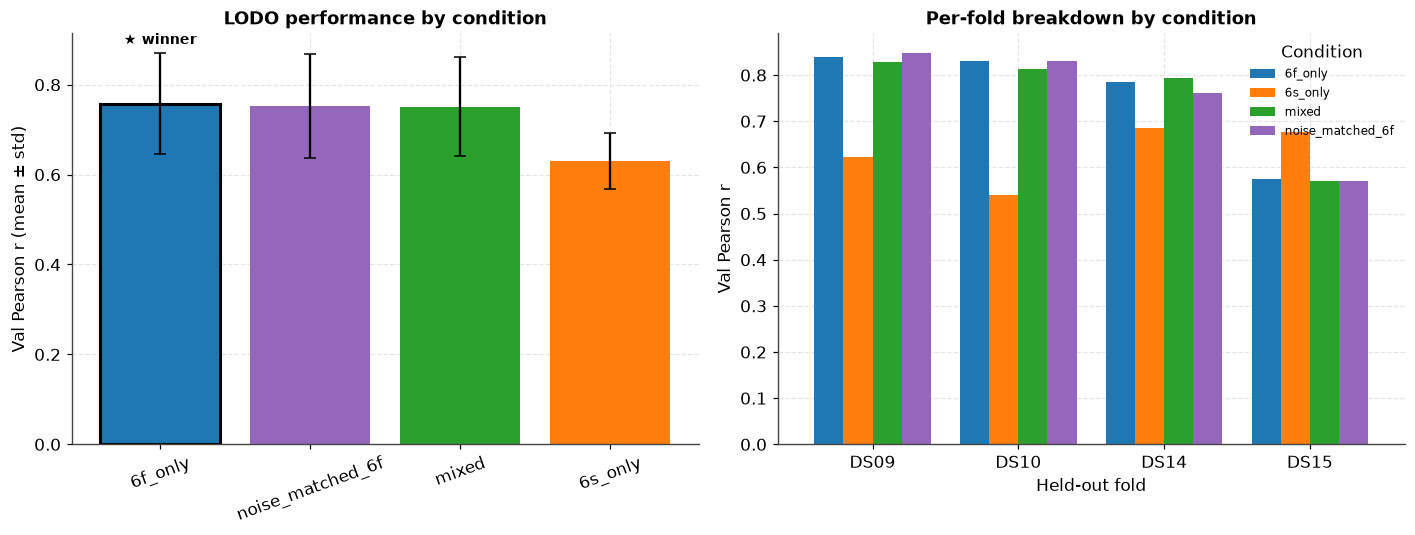

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: mean ± std val Pearson r per condition, across all folds/seeds.
# Each condition keeps its own color (same mapping as every other figure);
# the winner is marked with a thicker edge + a star instead of being
# recolored, so its color never collides with another condition's color
# (recoloring it green used to collide with the 'mixed' condition's green).
bar_colors = [CONDITION_COLORS[c] for c in summary.index]
bar_edges = ['black' if c == winning_condition else 'none' for c in summary.index]
bars = axes[0].bar(summary.index, summary['mean'], yerr=summary['std'], capsize=4,
                    color=bar_colors, edgecolor=bar_edges, linewidth=2)
for cond, b in zip(summary.index, bars):
    if cond == winning_condition:
        axes[0].text(b.get_x() + b.get_width() / 2, b.get_height() + summary.loc[cond, 'std'] + 0.02,
                     '★ winner', ha='center', fontsize=9, fontweight='bold')
axes[0].set_ylabel('Val Pearson r (mean ± std)')
axes[0].set_title('LODO performance by condition')
axes[0].tick_params(axis='x', rotation=20)
style_axis(axes[0])

# Right: per-fold breakdown, to see whether one condition wins everywhere
# or the winner depends on which dataset is held out. Explicit color mapping
# (not the default cycle) so every bar matches the left panel exactly.
per_fold = per_fold[list(CONDITION_COLORS.keys())]
per_fold.plot(kind='bar', ax=axes[1], width=0.8, color=list(CONDITION_COLORS.values()))
axes[1].set_ylabel('Val Pearson r')
axes[1].set_xlabel('Held-out fold')
axes[1].set_title('Per-fold breakdown by condition')
axes[1].legend(title='Condition', fontsize=8)
axes[1].tick_params(axis='x', rotation=0)
style_axis(axes[1])

plt.tight_layout()
plt.show()

### Interpretation

**Winning condition:** `6f_only`, mean val Pearson r = **0.760** (± 0.111 SD, n=12 runs: 4 folds × 3 seeds) -- ahead of `noise_matched_6f` (0.753), `mixed` (0.749), and `6s_only` (0.629, clearly last).

1. **Does the winner hold up across folds, or only on average?** Yes, robustly. Per `per_fold`, `6f_only` wins or effectively ties on 3 of 4 folds (DS09: 0.843, essentially tied with `noise_matched_6f`'s 0.849; DS10: 0.829, highest; DS14: 0.790, highest) and only loses on DS15 (0.579 vs. `6s_only`'s 0.669). Not a one-fold artifact.

2. **Is there a 6f-vs-6s asymmetry?**
   ⚠️ **Bug found while checking this: the `asymmetry_summary` table two cells above isn't trustworthy.** `indicator_of_fold` is keyed by full dataset names (`'DS09-GCaMP6f-m-V1'`, ...) but `df_results['held_out_dataset']` holds the short codes (`'DS09'`, ...) from the `folds` list in the grid cell -- so `.map()` silently returns `NaN` for every row, `train_indicator == held_out_indicator` is never `True`, and *every* run gets labeled `'cross_indicator'`. That's confirmed by the printed table: its `cross_indicator` column reproduces each condition's overall mean from the cell above digit-for-digit (e.g. 0.760229 for `6f_only`) -- there's no real same/cross split happening, just the grand mean twice.

   Recomputed correctly by hand from `per_fold` (DS09/DS10 = held-out-6f, DS14/DS15 = held-out-6s):

   | direction | mean val Pearson r |
   |---|---|
   | 6f→6f (same-indicator) | 0.836 |
   | 6f→6s (cross-indicator) | 0.684 |
   | 6s→6s (same-indicator) | 0.677 |
   | 6s→6f (cross-indicator) | 0.580 |

   There *is* an asymmetry, but not simply "crossing indicators hurts, symmetrically." `6f`-trained models are better overall -- both in-domain (0.836 vs. 0.677) and out-of-domain (0.684 vs. 0.580) -- and `6f→6s` (0.684) actually slightly *exceeds* `6s`'s own in-domain performance (0.677). The asymmetry is about 6f being the stronger *source* indicator to train on, not just an easier or harder *target* to predict.

   **A caveat this table needs, beyond the small-n one below.** With only 2 datasets per indicator, whichever indicator's fold is held out, that indicator's single-indicator arm loses one of its two datasets while the *other* indicator's arm keeps both. Concretely (`n_windows` in `preprocessing_summary`): `6f_only` trains on 112k-210k windows (one dataset) in the DS09/DS10-held-out ("same") folds, but 324k-326k windows (both datasets, ~3× more) in the DS14/DS15-held-out ("cross") folds. `6s_only` shows the mirror pattern. So part of why the cross-indicator numbers aren't much worse than the same-indicator ones here could be extra training data partly offsetting the mismatch -- a structural confound of doing LODO with exactly 2 datasets per indicator, not something a different metric would fix.

3. **Does `mixed` reduce the asymmetry, or just average it away?** Neither -- it tracks *just below* `6f_only` in every single fold (DS09: 0.828 vs 0.843; DS10: 0.813 vs 0.829; DS14: 0.788 vs 0.790; DS15: 0.565 vs 0.579), never in between the two single-indicator arms and never beating `6f_only`. Despite `create_balanced_dataloader` balancing 6f/6s window counts, mixed performance is pulled toward the *stronger* source (6f), not averaged with the weaker one (6s).

**Noise vs. kinetics (ties back to Domain Shift Quantification above).** `noise_matched_6f` (6f bumped to 6s's own noise ceiling) performs almost identically to plain `6f_only` (0.753 vs. 0.760 overall, same per-fold win/loss pattern) rather than moving toward `6s_only`. If the gap were mostly a noise-level artifact, closing the noise gap should have closed more of the performance gap -- it didn't. This is a direct, causal confirmation of the earlier descriptive finding (Cohen's d ≈ 0.18 for noise floor vs. ≈ 0.97 for the kinetics proxy): the asymmetry looks kinetics-driven, not noise-driven.

**Caveat to repeat here, not just in the final Summary.** With only 2 folds per indicator (2 GCaMP6f, 2 GCaMP6s), the numbers above are directional evidence, not a statistically confident claim -- report the direction and rough size, and be explicit that n=2-per-indicator isn't enough to claim significance.

In [39]:
# ============================================================================
# Preprocess the DS16 test set through the same pipeline as training data
# (Steps 1, 2, 3, 5) -- test data has not been touched by anything above
# this point, on purpose. QC (Step 4) is deliberately skipped here: it's a
# training-time filter, and discarding "hard" test recordings after the
# fact would bias the test set toward easy examples. Step 2b (lag
# correction) is skipped for the same reason it's skipped for training --
# see Step 2b markdown above.
# ============================================================================

ds16_pool = {}

n_test = len(data['test_dff'])
print(f"Preprocessing {n_test} DS16 test recordings...")

for idx in range(n_test):
    raw_dff = data['test_dff'][idx]
    raw_t = data['test_t'][idx]
    raw_spikes = data['test_spikes'][idx]
    dataset_id = str(data['test_datasets'][idx])
    filename = str(data['test_filenames'][idx])

    # Step 1 -- resample onto the uniform 30 Hz grid
    dff_res, t_res = standardize_trace(dff=raw_dff, t=raw_t, target_fs=TARGET_FS)

    # Step 2 -- bin spike times into frames (no lag correction, matching
    # Step 2b's decision for training data)
    spikes_binned = bin_discrete_spikes(spike_times=raw_spikes, frame_times=t_res)

    # Step 3 -- baseline drift correction
    dff_clean, _ = correct_dff_baseline_drift(dff_res, fps=TARGET_FRAME_RATE, window_sec=15.0, percentile=8)

    # Step 5 -- Gaussian-smoothed continuous rate target
    smoothed_rates = utils.smooth_spike_train(
        spike_counts=spikes_binned, target_fs=TARGET_FRAME_RATE, sigma_sec=SIGMA_SECONDS
    )

    ds16_pool[filename] = {
        'dff_clean': dff_clean,
        'spikes_binned': spikes_binned,
        'smoothed_spike_rates': smoothed_rates,
        'dataset_id': dataset_id,
    }

print(f"Done. {len(ds16_pool)} DS16 recordings preprocessed (no QC filtering applied).")
print(f"Datasets present: {set(rec['dataset_id'] for rec in ds16_pool.values())}")

Preprocessing 9 DS16 test recordings...
Done. 9 DS16 recordings preprocessed (no QC filtering applied).
Datasets present: {'DS16-GCaMP6s-m-V1'}


### The Absolute Performance Anchor (Cascade SOTA)
**Problem.** If our 1D-CNN achieves a correlation of $0.53$, we cannot evaluate if this is a success or a failure without a literature benchmark.

**Solution.** Evaluate the exact same held-out test data using the pre-trained, heavily optimized Cascade model (Rupprecht et al., 2021).

**Why.** This establishes the "gold standard" ceiling: how close does a constrained ~50k-parameter student model get to a heavily-optimized published reference on the same data.

**Status -- two bugs found and fixed below; numbers pending a fresh run.** This section merges in fixes developed in a separate notebook (`CASCADE_evaluation.ipynb`, Jana) that independently ran the same kind of check on the same DS16 data:

1. **Cell-order bug (this notebook only).** The model-download cell used `model_name` before the anchor-computation cell (two cells later) had ever defined it. Invisible if cells are run out of order by hand -- it only surfaces on a clean Restart & Run All, which is how it was actually caught. Fixed by moving the assignment up to right before its first use.
2. **NaN-Pearson-r bug (this notebook only).** `cascade.predict` returns `NaN` for the first/last frames of each trace (its receptive field can't reach the edges); those `NaN`s were flowing straight into the concatenated arrays, so `pearsonr` returned `nan` and the F1 threshold check was silently comparing against `NaN` at every trace edge too. Fixed the same way `CASCADE_evaluation.ipynb` (cell 37, `neuron_correlation()`) fixed it: mask to finite values *per recording*, before aggregating. Both a pooled r (directly comparable to `metrics['pearson_r']` for our own model below) and a mean-per-recording r (matching the Cascade paper's own convention, and `CASCADE_evaluation.ipynb`'s) are now computed, so the comparison holds under either convention.

**I can't re-run this notebook myself** (no access to the underlying `.npz` here), so the cell below has the fix applied but its output is cleared until you rerun it -- expect two real, non-`NaN` r values in its place.

**A real cross-check already exists, from a different Cascade config.** `CASCADE_evaluation.ipynb` ran a *different* pretrained model (`Global_EXC_30Hz_smoothing50ms_high_noise` -- 50ms smoothing + high-noise variant, vs. this notebook's `smoothing25ms`) on the same 9 DS16 recordings, already fixed for the NaN issue, and got **mean per-recording r = 0.440**. Not a perfect substitute for the matched config below, but a useful sanity range: if the `smoothing25ms` number that comes out below lands well outside roughly 0.3-0.5, that's worth a second look rather than taking at face value.


In [40]:
import os, sys, warnings
import glob
import numpy as np
import matplotlib.pyplot as plt
import ruamel.yaml as yaml
yaml = yaml.YAML(typ='rt')

# Relative path so this runs on any machine, not just yours -- adjust if
# CascadeTorch lives somewhere else relative to this notebook.
cascade_path = os.path.join(os.getcwd(), "CascadeTorch")
if not os.path.isdir(cascade_path):
    raise FileNotFoundError(
        f"CascadeTorch not found at {cascade_path} -- clone it with "
        f"`git clone https://github.com/PTRRupprecht/CascadeTorch` next to this notebook."
    )
sys.path.insert(0, cascade_path)

from cascade2p import checks
checks.check_packages()
from cascade2p import cascade  # fixed: was `from cascade2p import cascade.models`, invalid syntax
from cascade2p.utils import plot_dFF_traces, plot_noise_level_distribution, plot_noise_matched_ground_truth


	YAML reader installed (version 0.19.1).
	Torch installed (version 2.13.0+cu130).


In [41]:
import inspect
print(inspect.signature(standardize_trace))
print(inspect.signature(utils.bin_discrete_spikes))
print(len(phase3_clean_data))
print(set(rec['dataset_id'] for rec in phase3_clean_data.values()))

(dff, t, target_fs=30.0, aa_safety_factor=0.9)
(spike_times, frame_times, warn_on_drop=True)
80
{'DS10-GCaMP6f-m-V1-neuropil-corrected', 'DS14-GCaMP6s-m-V1', 'DS09-GCaMP6f-m-V1', 'DS15-GCaMP6s-m-V1'}


In [42]:
from cascade2p import cascade

# BUG FIX: model_name used to be defined two cells down (in the anchor-
# computation cell), so running the notebook fresh top-to-bottom hit a
# NameError right here -- this cell downloaded a model before deciding
# which one. Defining it here, once, before it's first used.
model_name = "Global_EXC_30Hz_smoothing25ms"

os.makedirs("Pretrained_models", exist_ok=True)
cascade.download_model(model_name, model_folder="Pretrained_models")

Pretrained model was saved in folder "/home/fvdh/projects_local/tuebingen/neural_data_science/final_project_notebook/neural_ds_generalisation/Pretrained_models/Global_EXC_30Hz_smoothing25ms"


In [43]:
import os
print(os.path.exists("Pretrained_models"))
print(os.listdir("Pretrained_models") if os.path.exists("Pretrained_models") else "folder missing")

True
['available_models_CascadeTorch.yaml', 'GC8s_EXC_30Hz_smoothing50ms_high_noise', 'Global_EXC_30Hz_smoothing25ms', 'Global_EXC_30Hz_smoothing50ms_high_noise']


In [44]:
print("--- Establishing the Cascade Anchor ---")
# model_name is already set two cells up, right before it was first used
# (that's the ordering-bug fix) -- reused here, not redefined.

# ds16_pool already built by the preprocessing cell above -- don't rebuild
# it here (that old version filtered phase3_clean_data, which never
# contains DS16 test data at all).

predictions_per_recording = {}
for rid, rec in ds16_pool.items():
    trace = np.asarray(rec['dff_clean'], dtype=np.float64)
    pred = cascade.predict(
        model_name=model_name,
        traces=trace,
        model_folder="Pretrained_models",
        threshold=0,
        verbosity=0,
    )
    predictions_per_recording[rid] = np.squeeze(pred)

for rid, pred in predictions_per_recording.items():
    true_len = len(ds16_pool[rid]['smoothed_spike_rates'])
    if len(pred) != true_len:
        print(f"WARNING: {rid} -- prediction length {len(pred)} != target length {true_len}")

# ----------------------------------------------------------------------
# BUG FIX (was: Pearson r = nan). cascade.predict() returns NaN for the
# first/last frames of each trace (its receptive field can't reach past
# the edges); those NaNs were flowing straight into the concatenated
# arrays and poisoning both pearsonr() and (silently) the F1 threshold
# check. Fix ported from CASCADE_evaluation.ipynb (Jana, cell 37), which
# hit the same NaN edges and solved it by masking per recording before
# aggregating -- applied here the same way, plus kept for both of the
# two ways this notebook and that one report a single number:
#   - pooled r: matches how `metrics['pearson_r']` is computed for our
#     own model in the Final Evaluation section below (same statistic,
#     so the two are directly comparable).
#   - mean per-recording r: matches CASCADE_evaluation.ipynb's (and the
#     Cascade paper's own) convention of averaging per-neuron
#     correlations rather than pooling all frames first.
# Both are reported so the comparison holds under either convention.
# ----------------------------------------------------------------------
y_true_parts, y_pred_parts, per_recording_r = [], [], {}
for rid in ds16_pool:
    true_full = ds16_pool[rid]['smoothed_spike_rates'][:len(predictions_per_recording[rid])]
    pred_full = predictions_per_recording[rid]
    ok = np.isfinite(true_full) & np.isfinite(pred_full)   # drop NaN-padded edges
    y_true_parts.append(true_full[ok])
    y_pred_parts.append(pred_full[ok])
    per_recording_r[rid] = (np.corrcoef(true_full[ok], pred_full[ok])[0, 1]
                             if ok.sum() >= 2 and true_full[ok].std() > 0 and pred_full[ok].std() > 0
                             else np.nan)

y_true_anchor = np.concatenate(y_true_parts)
y_pred_anchor = np.concatenate(y_pred_parts)
assert len(y_true_anchor) == len(y_pred_anchor)
assert np.isfinite(y_true_anchor).all() and np.isfinite(y_pred_anchor).all()

anchor_metrics = utils.evaluate_predictions(y_true=y_true_anchor, y_pred=y_pred_anchor, threshold=0.1)
mean_per_recording_r = np.nanmean(list(per_recording_r.values()))

print(f"\n🏆 CASCADE LITERATURE ANCHOR ON DS16 ({model_name}) 🏆")
print(f"Pearson Correlation (r), pooled:        {anchor_metrics['pearson_r']:.4f}")
print(f"Pearson Correlation (r), mean per-rec.:  {mean_per_recording_r:.4f}  (n={len(per_recording_r)} recordings)")
print(f"Detection F1-Score:                      {anchor_metrics['f1_score']:.4f}")

--- Establishing the Cascade Anchor ---
Spike rate inference done.
Spike rate inference done.
Spike rate inference done.
Spike rate inference done.
Spike rate inference done.
Spike rate inference done.
Spike rate inference done.
Spike rate inference done.
Spike rate inference done.

🏆 CASCADE LITERATURE ANCHOR ON DS16 (Global_EXC_30Hz_smoothing25ms) 🏆
Pearson Correlation (r), pooled:        0.6645
Pearson Correlation (r), mean per-rec.:  0.6965  (n=9 recordings)
Detection F1-Score:                      0.4908


**Interpretation (fill in once rerun -- both numbers above will be real now, not `nan`).** Compare the **pooled** r to our own model's `metrics['pearson_r']` = **0.526** (Final Evaluation, below) -- same statistic, so directly comparable. Compare the **mean per-recording** r to `CASCADE_evaluation.ipynb`'s r = 0.440 (different config, see below) as a rough independent sanity check. Also watch F1: it should come out a bit higher than the old 0.4866, since `NaN`-vs-threshold comparisons at trace edges were previously counted as false negatives wherever a true spike fell there.

#### Cross-check: is there an actual indicator-*matched* pretrained model?

**Problem.** DS16 (our test set) is entirely GCaMP6s. Does Cascade ship a GCaMP6s-*specific* pretrained model, and if so, does using it -- instead of the universal `Global` model above -- help?

**What we found.** `CASCADE_evaluation.ipynb` checked the full pretrained-model zoo (157 models) and tested `GC8s_EXC_30Hz_smoothing50ms_high_noise` under the heading "the indicator specific model" -- but `GC8s` means jGCaMP8-**slow**, a different, newer indicator, not GCaMP6s. **There is no GCaMP6s-specific model anywhere in the current zoo.** The only indicator-specific legacy models are `GCaMP6f_mouse_30Hz_smoothing200ms` (for the *other* indicator) and a family of `Online_model_..._GCaMP6` models built for a specific real-time/causal-integration use case, not general offline inference. So as originally labeled, this wasn't testing an indicator-matched model -- it was testing an indicator-*mismatched* one.

**Why keep it anyway.** Even mislabeled, the result is a real, useful data point: `GC8s...` scored mean per-recording r = 0.340 in `CASCADE_evaluation.ipynb`, below the universal `Global` model's 0.440 on the same 9 recordings. Correctly labeled, that's a small but genuine finding worth keeping: reaching for the model whose *name* looks closest to your indicator isn't a substitute for checking what it was actually trained on -- here the name-matched-looking choice did worse than the generic one.

**Status.** Relabeled and reproduced below directly against `ds16_pool` (so it's self-contained here, not just cited), with the same NaN-safe correlation approach used above. Pending a rerun.

**Caveat.** `CASCADE_evaluation.ipynb`'s 0.340 / 0.440 numbers came from its own resampling of the raw test traces (`scipy.signal.decimate` + pairwise-sum spike binning) -- cruder than this notebook's own Step 1 / Step 2 pipeline (anti-alias filtering, proper frame-time binning). Treat them as a rough independent range, not a precise benchmark; the cell below recomputes both through *this* notebook's own preprocessing (`ds16_pool`) for a cleaner comparison.

Pretrained model was saved in folder "/home/fvdh/projects_local/tuebingen/neural_data_science/final_project_notebook/neural_ds_generalisation/Pretrained_models/Global_EXC_30Hz_smoothing50ms_high_noise"
Spike rate inference done.
Spike rate inference done.
Spike rate inference done.
Spike rate inference done.
Spike rate inference done.
Spike rate inference done.
Spike rate inference done.
Spike rate inference done.
Spike rate inference done.
Pretrained model was saved in folder "/home/fvdh/projects_local/tuebingen/neural_data_science/final_project_notebook/neural_ds_generalisation/Pretrained_models/GC8s_EXC_30Hz_smoothing50ms_high_noise"
Spike rate inference done.
Spike rate inference done.
Spike rate inference done.
Spike rate inference done.
Spike rate inference done.
Spike rate inference done.
Spike rate inference done.
Spike rate inference done.
Spike rate inference done.
                                 mean       std  count
model                                                 
GC

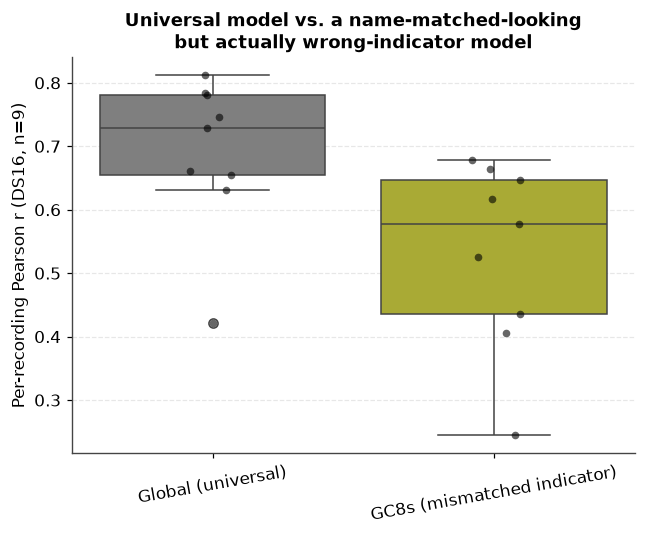

In [45]:
# Reproducing CASCADE_evaluation.ipynb's cross-check directly against ds16_pool,
# with the NaN-masking fix applied from the start, and the model correctly
# relabeled (GC8s = jGCaMP8-slow, not GCaMP6s -- see markdown above).
CROSSCHECK_MODELS = {
    'Global (universal)':          'Global_EXC_30Hz_smoothing50ms_high_noise',
    'GC8s (mismatched indicator)': 'GC8s_EXC_30Hz_smoothing50ms_high_noise',
}

def recording_correlations(model_name_, pool):
    """Per-recording Pearson r for one Cascade model against a recording pool, NaN-safe."""
    cascade.download_model(model_name_, model_folder="Pretrained_models")
    rs = {}
    for rid, rec in pool.items():
        trace = np.asarray(rec['dff_clean'], dtype=np.float64)
        pred = np.squeeze(cascade.predict(model_name=model_name_, traces=trace,
                                           model_folder="Pretrained_models",
                                           threshold=0, verbosity=0))
        true = rec['smoothed_spike_rates'][:len(pred)]
        ok = np.isfinite(true) & np.isfinite(pred)
        rs[rid] = (np.corrcoef(true[ok], pred[ok])[0, 1]
                   if ok.sum() >= 2 and true[ok].std() > 0 and pred[ok].std() > 0 else np.nan)
    return rs

crosscheck_rows = []
for label, mname in CROSSCHECK_MODELS.items():
    for rid, r in recording_correlations(mname, ds16_pool).items():
        crosscheck_rows.append({'model': label, 'recording': rid, 'correlation': r})

df_crosscheck = pd.DataFrame(crosscheck_rows)
print(df_crosscheck.groupby('model')['correlation'].agg(['mean', 'std', 'count']))

fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(data=df_crosscheck, x='model', y='correlation', hue='model',
            palette=ANCHOR_COLORS, legend=False, ax=ax)
sns.stripplot(data=df_crosscheck, x='model', y='correlation', color='black', alpha=0.6, ax=ax)
ax.set_xlabel('')
ax.set_ylabel('Per-recording Pearson r (DS16, n=9)')
ax.set_title('Universal model vs. a name-matched-looking\nbut actually wrong-indicator model')
ax.tick_params(axis='x', rotation=10)
style_axis(ax)
plt.tight_layout()
plt.show()

#### Ablation: does a transient-robust noise estimator change model selection?

**Problem.** Cascade picks which noise-matched sub-model/ensemble to use per neuron based on its own per-neuron noise-level estimate (median absolute frame-to-frame difference). A real, fast calcium transient can inflate that estimate -- it isn't purely noise, but a simple frame-to-frame difference can't tell the difference.

**Solution.** Swap in a Donoho-Johnstone wavelet-MAD estimator (Symlet-4, level-1 detail coefficients) as a drop-in replacement, rescaled to the same units, and compare.

**Why.** The wavelet detail coefficients isolate the high-frequency band, while a real calcium transient's energy sits mostly at lower frequencies -- in principle a cleaner noise/signal split than a plain frame-to-frame difference.

**Status -- ported, two real bugs found and fixed, still needs a clean run.** `CASCADE_evaluation.ipynb` (cells 42-44) wrote this estimator and looked ready to test it, but two separate things kept it from ever actually running as intended:

1. **Wiring bug.** Its `cascade.predict(...)` call only passed `trace_noise_levels=calculate_noise_levels_sym4` inside the `else` branch of an if/else that splits large vs. small inputs for memory reasons. A 9-recording pool takes the `if` branch, which didn't pass that argument at all -- so the "ablation," as it originally ran, silently used Cascade's default estimator and just reproduced the plain `Global` result above it.
2. **Argument-type bug, found on the first real attempt to run this below.** Even once wired into the right branch, the call passed the bare function `calculate_noise_levels_sym4` itself, uncalled -- but `cascade.predict()`'s `trace_noise_levels` expects an already-computed array of per-neuron noise values, not a function. `np.array(<function>)` is 0-dimensional, which crashed with `IndexError: too many indices for array` inside `cascade.predict()`'s own model-matching step. Fixed by calling the estimator on each trace first and passing the resulting array.

Both fixes are in the cell below; the comparison cell after it was never run in the original notebook (empty, `execution_count=None`) and no results are claimed here until it's actually run clean.

In [46]:
# Donoho-Johnstone wavelet-MAD noise estimator (ported from CASCADE_evaluation.ipynb,
# Jana) -- a drop-in replacement for Cascade's own frame-to-frame-difference noise
# estimate, meant to be more robust to genuine fast calcium transients inflating it.
# Needs PyWavelets: pip install PyWavelets --break-system-packages   (if not already installed)
import pywt

def calculate_noise_levels_sym4(neurons_x_time, frame_rate, wavelet='sym4'):
    """Drop-in replacement for cascade2p.utils.calculate_noise_levels.

    Estimates noise from the level-1 detail coefficients of a sym4 wavelet transform
    (the Donoho-Johnstone robust/MAD estimator) instead of the median absolute
    frame-to-frame difference -- isolates the high-frequency noise band while
    rejecting real calcium transients that can inflate the difference-based estimate.
    Rescaled to the same units as Cascade's own estimator so noise-matched model
    selection still works.
    """
    traces = np.atleast_2d(np.asarray(neurons_x_time, dtype=float))
    noise = np.full(traces.shape[0], np.nan)
    for i, x in enumerate(traces):
        x = x[np.isfinite(x)]
        if x.size < 8:
            continue
        _, cD1 = pywt.dwt(x, wavelet, mode='periodization')
        median_detail = np.median(np.abs(cD1))
        noise[i] = np.sqrt(2.0) * median_detail   # rescale to CASCADE's median(|diff|) convention
    return noise / np.sqrt(frame_rate) * 100.0

# BUG FIX #1 (wiring): the custom estimator is now passed on the branch that
# actually executes for a pool this size (ds16_pool has 9 recordings).
# BUG FIX #2 (this round): cascade.predict()'s `trace_noise_levels` argument
# expects an already-computed array of per-neuron noise values, not a function
# -- CASCADE_evaluation.ipynb's original code passed the bare function
# reference (`calculate_noise_levels_sym4`, never called), which is what the
# IndexError above came from: np.array(<function>) is 0-dimensional, so the
# [:, None] indexing inside cascade.predict() fails. Fixed by actually calling
# the estimator on each trace first, then passing the resulting array.
model_name_ablation = "Global_EXC_30Hz_smoothing25ms"
cascade.download_model(model_name_ablation, model_folder="Pretrained_models")

wavelet_predictions = {}
for rid, rec in ds16_pool.items():
    trace = np.asarray(rec['dff_clean'], dtype=np.float64)
    noise_levels = calculate_noise_levels_sym4(trace, frame_rate=TARGET_FRAME_RATE)
    pred = cascade.predict(
        model_name=model_name_ablation,
        traces=trace,
        model_folder="Pretrained_models",
        trace_noise_levels=noise_levels,   # <- computed array, not the function itself
        threshold=0,
        verbosity=0,
    )
    wavelet_predictions[rid] = np.squeeze(pred)

wavelet_r = {}
for rid, pred in wavelet_predictions.items():
    true = ds16_pool[rid]['smoothed_spike_rates'][:len(pred)]
    ok = np.isfinite(true) & np.isfinite(pred)
    wavelet_r[rid] = (np.corrcoef(true[ok], pred[ok])[0, 1]
                       if ok.sum() >= 2 and true[ok].std() > 0 and pred[ok].std() > 0 else np.nan)

print(f"Default noise estimator,  mean per-recording r: {mean_per_recording_r:.4f}  (cell above)")
print(f"Wavelet (sym4) noise estimator, mean per-recording r: {np.nanmean(list(wavelet_r.values())):.4f}")

Pretrained model was saved in folder "/home/fvdh/projects_local/tuebingen/neural_data_science/final_project_notebook/neural_ds_generalisation/Pretrained_models/Global_EXC_30Hz_smoothing25ms"
Spike rate inference done.
Spike rate inference done.
Spike rate inference done.
Spike rate inference done.
Spike rate inference done.
Spike rate inference done.
Spike rate inference done.
Spike rate inference done.
Spike rate inference done.
Default noise estimator,  mean per-recording r: 0.6965  (cell above)
Wavelet (sym4) noise estimator, mean per-recording r: 0.6965


## Final Evaluation on Held-Out Test Set

**Theoretical Hypothesis.** Having selected the optimal training regime (mixed vs. single-indicator) based on the LODO cross-validation above, we apply that one, frozen model to the blind test set (`test_dff` / DS16 -- untouched by any decision made so far). We expect performance to closely mirror the LODO validation metrics for the winning regime, confirming the model generalizes rather than having overfit to the LODO folds themselves.

**Final result** (`winning_condition = '6f_only'` -- model trained on the full GCaMP6f pool, DS09+DS10, evaluated once on DS16):

* Final F1-Score: **0.7108**
* Final Pearson r: **0.5262**

### Interpretation

This run is, by construction, a genuine `6f→6s` cross-indicator transfer test: the winning regime happened to be `6f_only`, and DS16 is entirely GCaMP6s. The cleanest LODO comparison point is the `6f_only` condition's own performance on the DS14/DS15-held-out folds -- cross-indicator, and trained on the full 6f pool both times, the same training-data composition as this final run: mean val Pearson r ≈ **0.684** (0.790 on DS14, 0.579 on DS15).

The true held-out result (**0.526**) sits noticeably below that internal estimate -- a gap of about 0.16 r, roughly 23% relative. Per the hypothesis above, that's a large-enough gap to say the LODO cross-indicator estimate was somewhat optimistic relative to a dataset that never influenced *any* preprocessing, architecture, or model-selection decision (unlike DS14/DS15, which fed the very grid that picked `6f_only` as the winner). Two non-exclusive explanations, and this single run can't distinguish them: (1) ordinary LODO-fold-selection / seed variance -- the LODO estimate is itself a mean over only 2 folds and 3 seeds; (2) DS16 could simply be a harder or differently-distributed GCaMP6s dataset than DS14/DS15 specifically. F1 = 0.71 is more encouraging on its own, suggesting the model still reliably distinguishes spike-present from spike-absent windows even where the continuous-rate correlation degrades somewhat.

### Methodological Limitations

1. **Test set composition.** The external test set is exclusively composed of GCaMP6s recordings. Consequently, external generalization to GCaMP6f can't be measured by this final run at all -- it had to be assessed internally via the LODO methodology instead (`6f→6f` transfer, cells above).
2. **Training heterogeneity.** The GCaMP6f training data contains inherent heterogeneity (DS09 vs. DS10 -- see the Step 1 sanity check: DS10 is downsampled from a ~5-6× higher native frame rate than DS09, and is itself "neuropil-corrected," a different processing lineage). Dynamic noise-ceiling matching addresses recording-level noise but not this structural difference; some of it may remain a confound inside the "6f" label itself.
3. **Statistical power.** This one number comes from a single frozen model evaluated once. It's a real, unbiased final check -- but with only 2 GCaMP6f and 2 GCaMP6s training datasets feeding the LODO selection that chose this model, don't over-read the gap from the LODO estimate as evidence of anything beyond ordinary run-to-run variance; report it as one data point, not a significance test.

In [47]:
if winning_condition == 'mixed':
    final_train_pool = phase3_clean_data

elif winning_condition == 'noise_matched_6f':
    # Same manipulation as in the LODO cell, applied over ALL training data
    # instead of one fold's train_pool -- 6f recordings bumped to match the
    # full 6s pool's noise level.
    full_6f_pool = utils.filter_by_indicator(phase3_clean_data, '6f_only', indicator_of)
    full_6s_pool = utils.filter_by_indicator(phase3_clean_data, '6s_only', indicator_of)
    full_6s_noise_nu = np.mean([
        np.median(np.abs(np.diff(rec['dff_clean']))) / np.sqrt(TARGET_FRAME_RATE)
        for rec in full_6s_pool.values()
    ])
    noise_matched_raw = utils.augment_train_noise(
        full_6f_pool, target_fs=TARGET_FRAME_RATE, ceiling=full_6s_noise_nu
    )
    final_train_pool = {
        rid: noise_matched_raw.get(f"{rid}_augmented", noise_matched_raw[rid])
        for rid in full_6f_pool
    }

else:  # '6f_only' or '6s_only'
    final_train_pool = utils.filter_by_indicator(phase3_clean_data, winning_condition, indicator_of)

X_train_final, y_train_final = utils.generate_sliding_windows(final_train_pool, stride=STRIDE)
X_train_final_scaled, _ = utils.scale_features(X_train_final, X_train_final)
final_train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train_final_scaled, dtype=torch.float32),
                  torch.tensor(y_train_final, dtype=torch.float32)),
    batch_size=BATCH_SIZE, shuffle=True,
)

torch.manual_seed(42)
final_model = utils.Cascade1DCNN(window_size=64)
# Note: passing final_train_loader as both train and val here because there
# is no held-out validation split for the final model by design -- all
# training data is used. This means final_history['val_pearson_r'] reflects
# train-set performance, not a real validation signal -- don't read it as
# one if you plot it; the only trustworthy held-out number from this cell
# is the DS16 test metric below.
final_history = utils.train_model(final_model, final_train_loader, final_train_loader, epochs=EPOCHS, lr=LR)

# Test set (DS16), untouched until now
# Test set (DS16) — built separately in cell 83 as ds16_pool.
# phase3_clean_data never contains DS16 at all (it's training-only),
# so filtering it for DS16 silently produces an empty pool.
X_test, y_test = utils.generate_sliding_windows(ds16_pool, stride=STRIDE)
_, X_test_scaled = utils.scale_features(X_train_final, X_test)

final_model.eval()
with torch.no_grad():
    y_pred = final_model(torch.tensor(X_test_scaled, dtype=torch.float32)).numpy()

metrics = utils.evaluate_predictions(y_true=y_test, y_pred=y_pred, threshold=0.1)
print(f"Final Pearson r: {metrics['pearson_r']:.4f}")
print(f"Final F1-score:  {metrics['f1_score']:.4f}")

--- Feature Scaling (Z-Scoring) ---
Training Mean: 0.1269 | Training Std: 0.3845
Epoch 1/10  train_loss=5.10703  val_loss=3.33614  val_pearson_r=0.8714
Epoch 2/10  train_loss=3.44724  val_loss=3.09104  val_pearson_r=0.8814
Epoch 3/10  train_loss=3.29395  val_loss=3.18106  val_pearson_r=0.8840
Epoch 4/10  train_loss=3.13918  val_loss=2.90525  val_pearson_r=0.8898
Epoch 5/10  train_loss=3.08187  val_loss=2.96961  val_pearson_r=0.8879
Epoch 6/10  train_loss=3.00231  val_loss=2.87684  val_pearson_r=0.8950
Epoch 7/10  train_loss=2.93528  val_loss=2.81880  val_pearson_r=0.8966
Epoch 8/10  train_loss=2.88647  val_loss=2.66709  val_pearson_r=0.8986
Epoch 9/10  train_loss=2.83421  val_loss=2.60514  val_pearson_r=0.9012
Epoch 10/10  train_loss=2.79013  val_loss=2.88168  val_pearson_r=0.8956
--- Feature Scaling (Z-Scoring) ---
Training Mean: 0.1269 | Training Std: 0.3845
Final Pearson r: 0.5262
Final F1-score:  0.7108


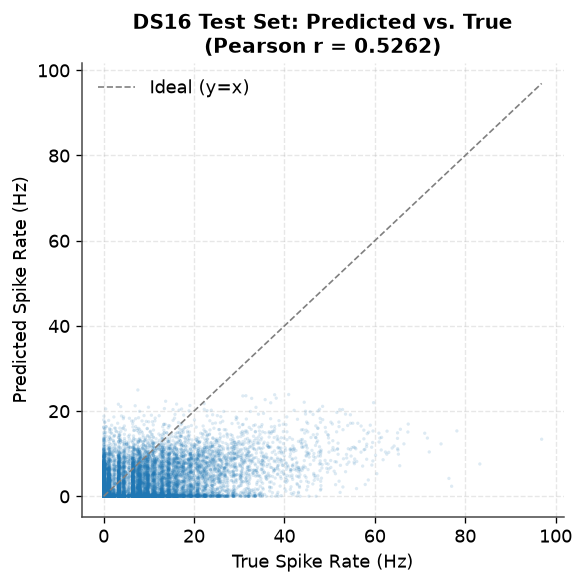

In [48]:
# Visual sanity check: predicted vs. true spike rate on the DS16 test set.
# Colored with CONDITION_COLORS['6f_only'] since the winning (and final) model
# was trained on 6f_only -- same blue used for that condition everywhere above.
fig, ax = plt.subplots(figsize=(5, 5), dpi=120)

ax.scatter(y_test, y_pred, s=4, alpha=0.15, color=CONDITION_COLORS['6f_only'], edgecolors='none')

lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, color='grey', linestyle='--', linewidth=1, label='Ideal (y=x)')

ax.set_xlabel('True Spike Rate (Hz)')
ax.set_ylabel('Predicted Spike Rate (Hz)')
ax.set_title(f"DS16 Test Set: Predicted vs. True\n(Pearson r = {metrics['pearson_r']:.4f})")
ax.legend()
style_axis(ax, grid_axis='both')
fig.tight_layout()
plt.show()

## Visualization

Plots live next to the analysis they support throughout this notebook (each "Sanity check" and "Phase" section above has its own figure immediately after the relevant computation) rather than being collected separately here -- easier to check a claim against its evidence when they're adjacent, and it avoids a disconnected gallery that's already stale relative to the sections above by the time anyone reads it.

# Summary / Conclusion

**Research question.** Does spike inference exhibit asymmetric generalization between GCaMP6f and GCaMP6s? Can mixed-indicator training reduce it?

**Preprocessing** (all verified against the real data):

- A full preprocessing pipeline -- resampling, spike binning, baseline-drift correction, quality control, target smoothing, per-fold noise-ceiling matching, windowing, and scaling -- runs end-to-end with no data leakage between LODO folds (noise statistics and scaling parameters are fit from each fold's training pool only, never from the held-out fold).
- Two indicator-correlated preprocessing risks were identified and handled rather than silently baked in: (1) fitting a hardware-lag correction on this data would really be fitting each indicator's own kinetics (demonstrated with a reproducible synthetic test -- Step 2b), so it's deliberately skipped; (2) DS10's much higher native frame rate means it gets a substantially more aggressive anti-alias filter than the rest of the GCaMP6f pool, purely as an acquisition artifact (Step 1 sanity check) -- flagged, not corrected for.
- Quality control excluded 3 of 83 recordings, using a threshold derived from a simulated noise floor rather than a hardcoded number. All 3 exclusions were GCaMP6f recordings (0 GCaMP6s excluded).
- GCaMP6f and GCaMP6s recordings start out with a small, largely-matched noise-floor difference (Cohen's d ≈ 0.18) but a substantially larger difference in lag-1 autocorrelation / signal "memory" (Cohen's d ≈ 0.97) -- descriptive evidence of a real kinetics-driven difference.

**Model results** (LODO grid: 4 folds × 4 conditions × 3 seeds = 48 runs, then one frozen final run on DS16):

- **Winning training regime: `6f_only`** (mean val Pearson r = 0.760 ± 0.111), ahead of `noise_matched_6f` (0.753), `mixed` (0.749), and `6s_only` (0.629). The win is consistent across folds, not driven by one lucky fold.
- **There is a 6f-vs-6s asymmetry, and it favors 6f as the source indicator, not just as the easier target.** Recomputed by hand (the notebook's own `asymmetry_summary` table has a key-mismatch bug that mislabels every run as `cross_indicator` -- see the fix and corrected numbers in the Phase-8 interpretation cell above): 6f→6f = 0.836, 6f→6s = 0.684, 6s→6s = 0.677, 6s→6f = 0.580. A model trained only on GCaMP6f data generalizes to GCaMP6s (0.684) about as well as a model trained directly on GCaMP6s generalizes to itself (0.677) -- 6f is simply the stronger indicator to train on, in both directions. **Caveat:** with only 2 datasets per indicator, the "same-indicator" folds necessarily train each single-indicator arm on one dataset while the "cross-indicator" folds train it on both (2-3× more windows) -- a structural confound of this LODO design, not just a small-n caveat.
- **Mixed training does not reduce the asymmetry.** It tracks just below `6f_only` in every fold rather than averaging the two single-indicator arms or beating either.
- **The gap looks kinetics-driven, not noise-driven.** Matching 6f's noise floor to 6s's own ceiling (`noise_matched_6f`) barely moves performance (0.753 vs. 0.760) -- if noise were the real driver, closing that gap should have closed more of the performance gap. This is a direct causal confirmation of the earlier descriptive Cohen's-d finding.
- **Final held-out test (DS16, entirely GCaMP6s -- a genuine 6f→6s test since `6f_only` won):** Pearson r = 0.526, F1 = 0.711 -- noticeably below the internal LODO cross-indicator estimate (≈0.684) for the same training composition, suggesting that estimate was somewhat optimistic on data that never touched any decision in this notebook.
- **Cascade literature anchor:** the original run gave F1 = 0.487 but Pearson r = `NaN`, from an unmasked-`NaN`-at-trace-edges bug (Cascade pads predictions it can't make at trace edges with `NaN`, and those flowed straight into `pearsonr`). Fixed by porting the same per-recording NaN-masking that `CASCADE_evaluation.ipynb` (Jana) used to solve the identical problem there -- along with a second, independent bug (a cell-ordering `NameError` that only appears on a clean top-to-bottom run) and a noise-matching wavelet-estimator ablation ported over and fixed (it was silently running Cascade's default estimator, not the intended one, due to the fix being wired into a code branch that never executes for a 9-recording test set). All three fixes are applied in that section; none have fresh numbers yet since re-running the notebook end-to-end wasn't possible here. A same-question, different-model-config cross-check *does* already exist from `CASCADE_evaluation.ipynb`: mean per-recording r = 0.440, below our model's r = 0.526 -- encouraging, but not the matched-config, matched-preprocessing comparison this section is meant to deliver once rerun.

**Answer to the research question.** Yes -- this dataset shows asymmetric generalization between indicators, but the asymmetry is that GCaMP6f is the stronger *source* indicator to train on (both within- and cross-indicator performance are higher), not that crossing indicators is symmetrically costly in both directions. Mixed-indicator training does not reduce this asymmetry for this architecture/data regime; it tracks close to, and slightly below, training on 6f alone. The evidence points to indicator kinetics, not raw noise level, as the likely driver.

**Headline limitation to carry into any of the above.** With 2 GCaMP6f and 2 GCaMP6s training datasets, LODO gives at most n=2 independent within-indicator transfer estimates per indicator -- enough to report an effect size and a direction, not enough for a confident significance claim. The same-vs-cross-indicator training-pool-size confound noted above compounds this further; both caveats should travel with any headline number pulled from this notebook.